<a href="https://colab.research.google.com/github/gitbidec6/Machine-Learning-Works/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [72]:
import pandas as pd

# Load the dataset (adjust the path as per your environment)
compressive_data = pd.read_excel('/content/sample_data/Recycled.xlsx')  # Replace with your file path

# Check for missing values
missing_values = compressive_data.isnull().sum()

# Print missing values summary
print(missing_values)


Cement                         0
Flyash                         0
GGBS                           0
MK                             0
Water                          0
SP                             0
VMA                            0
NCA_20                         0
NCA_10                         0
RCA_20                         0
RCA_10                         0
Sand                           0
Curing_Day                     0
Compressive Strength N/mm2)    0
dtype: int64


In [73]:
# Check unique values in the 'Curing_Day' column to identify any non-numeric data
print(compressive_data['Curing_Day'].unique())


[ 7 14 28 56  3 90]


In [74]:
# Feature Engineering: Create new features based on domain knowledge using compressive_data
# Example interaction features (adjust based on domain knowledge of concrete data)
compressive_data['Cement_Water_Interaction'] = compressive_data['Cement'] * compressive_data['Water']
compressive_data['Flyash_Water_Interaction'] = compressive_data['Flyash'] * compressive_data['Water']
compressive_data['GGBS_Water_Interaction'] = compressive_data['GGBS'] * compressive_data['Water']
compressive_data['MK_Water_Interaction'] = compressive_data['MK'] * compressive_data['Water']
compressive_data['SP_Water_Interaction'] = compressive_data['SP'] * compressive_data['Water']
compressive_data['VMA_Water_Interaction'] = compressive_data['VMA'] * compressive_data['Water']

compressive_data['NCA20_RCA20_Interaction'] = compressive_data['NCA_20'] * compressive_data['RCA_20']
compressive_data['NCA10_RCA10_Interaction'] = compressive_data['NCA_10'] * compressive_data['RCA_10']

compressive_data['Cement_Sand_Interaction'] = compressive_data['Cement'] * compressive_data['Sand']
compressive_data['Flyash_Sand_Interaction'] = compressive_data['Flyash'] * compressive_data['Sand']

# Add more relevant interaction features based on your understanding of the data

In [75]:
# Select features for model from compressive_data, including new interaction features
X = compressive_data.drop(columns=['Compressive Strength N/mm2)']) # Drop the target variable
y = compressive_data['Compressive Strength N/mm2)']

# Display the selected features to confirm
print("Selected features:")
print(X.columns)

Selected features:
Index(['Cement', 'Flyash', 'GGBS', 'MK', 'Water', 'SP', 'VMA', 'NCA_20',
       'NCA_10', 'RCA_20', 'RCA_10', 'Sand', 'Curing_Day',
       'Cement_Water_Interaction', 'Flyash_Water_Interaction',
       'GGBS_Water_Interaction', 'MK_Water_Interaction',
       'SP_Water_Interaction', 'VMA_Water_Interaction',
       'NCA20_RCA20_Interaction', 'NCA10_RCA10_Interaction',
       'Cement_Sand_Interaction', 'Flyash_Sand_Interaction'],
      dtype='object')


In [76]:
# Normalize the features using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

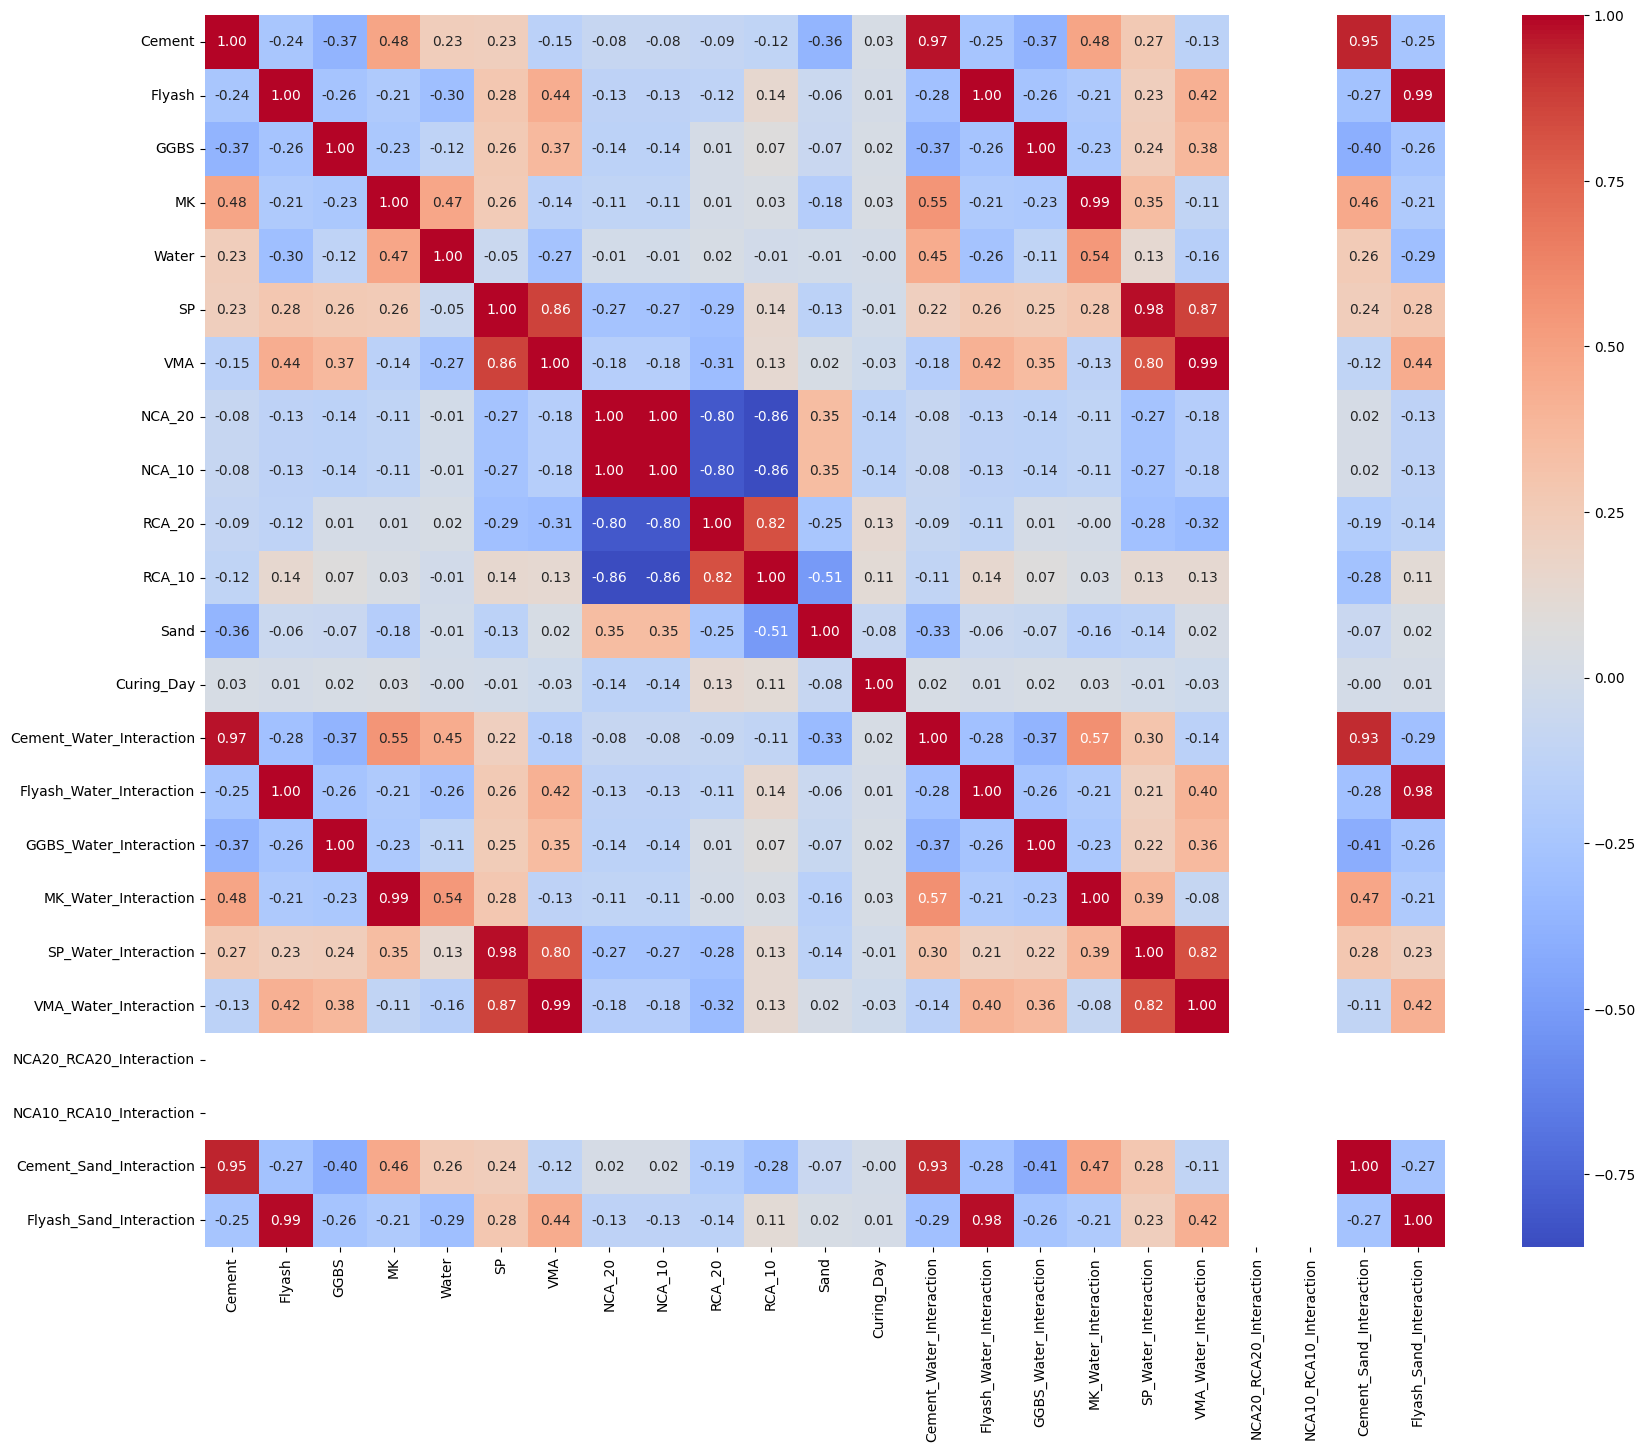

In [77]:
# Compute Pearson correlation for the features
correlation_matrix = pd.DataFrame(X_scaled, columns=X.columns).corr()

# Visualize the correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector

# Initialize Linear Regression model (used for feature selection)
model_lr = LinearRegression()

# Apply Backward Feature Selection (BSFS)
selector = SequentialFeatureSelector(model_lr, n_features_to_select="auto", direction='backward')
selector.fit(X_scaled, y)

# Get selected features
selected_features = X.columns[selector.get_support()]
print("Selected Features after BSFS:", selected_features)

Selected Features after BSFS: Index(['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
       'Cement_Water_Interaction', 'Flyash_Water_Interaction',
       'GGBS_Water_Interaction', 'VMA_Water_Interaction'],
      dtype='object')


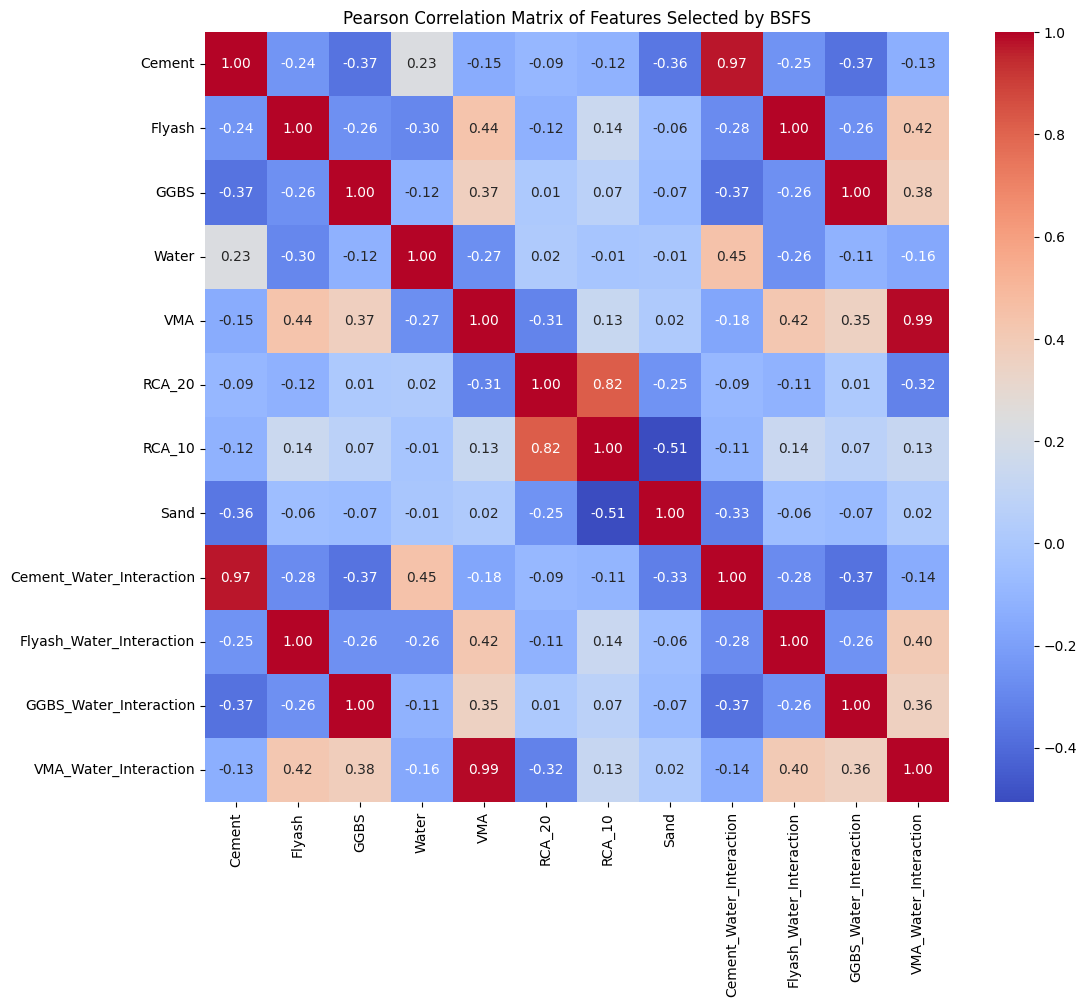

In [79]:
# prompt: Compute Pearson correlation for the Selected features after BSFS

import pandas as pd
import matplotlib.pyplot as plt
# Filter the scaled data to include only the selected features
X_selected_scaled = pd.DataFrame(X_scaled, columns=X.columns)[selected_features]

# Compute the Pearson correlation matrix for the selected features
correlation_matrix_selected = X_selected_scaled.corr()

# Visualize the correlation matrix for the selected features
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_selected, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Matrix of Features Selected by BSFS')
plt.show()

In [80]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Define the parameter grid for hyperparameter tuning of XGBoost
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, 30],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0]
}

# Initialize XGBoost Regressor
xgb_model = XGBRegressor(random_state=42)

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_scaled, y)

# Get best parameters
print(f'Best Parameters: {grid_search.best_params_}')

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 20, 'n_estimators': 150, 'subsample': 0.8}


In [81]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Assuming you have already defined X_scaled and y, which are your features and target variable.

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Convert the data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

# Define the BNN model
class BNN(nn.Module):
    def __init__(self, input_size):
        super(BNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize the BNN model
bnn_model = BNN(input_size=X_train.shape[1])

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(bnn_model.parameters(), lr=0.001)

# Training loop for BNN
num_epochs = 100
for epoch in range(num_epochs):
    # Forward pass
    outputs = bnn_model(X_train_tensor)

    # Compute loss
    loss = criterion(outputs, y_train_tensor)

    # Zero gradients, backward pass, optimizer step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:  # Print loss every 10 epochs
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 1469.6549
Epoch [20/100], Loss: 1437.2598
Epoch [30/100], Loss: 1385.8857
Epoch [40/100], Loss: 1307.7694
Epoch [50/100], Loss: 1195.2659
Epoch [60/100], Loss: 1042.9252
Epoch [70/100], Loss: 852.4995
Epoch [80/100], Loss: 638.4440
Epoch [90/100], Loss: 429.7686
Epoch [100/100], Loss: 264.4142


In [82]:
# Convert X_test to a PyTorch tensor (for BNN model)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

In [83]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor  # Import XGBoost
import math

# Initialize and train the XGBoost model
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)  # Ensure the model is trained

# Convert X_test to a PyTorch tensor for BNN predictions
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# Get predictions from the trained BNN model
bnn_predictions = bnn_model(X_test_tensor).detach().numpy()  # Convert tensor to numpy array

# Get predictions from the trained XGBoost model
xgb_predictions = xgb_model.predict(X_test)

# Combine predictions using weighted averaging
final_predictions = 0.5 * bnn_predictions.flatten() + 0.5 * xgb_predictions.flatten()

# Calculate RMSE manually (square root of mean squared error)
rmse = math.sqrt(mean_squared_error(y_test, final_predictions))

# Calculate MAE, MAPE, and R²
mae = mean_absolute_error(y_test, final_predictions)
mape = mean_absolute_percentage_error(y_test, final_predictions)
r2 = r2_score(y_test, final_predictions)

# Print evaluation metrics
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'MAPE: {mape}')
print(f'R²: {r2}')


RMSE: 10.61209529111185
MAE: 8.146378816303454
MAPE: 0.21893675239477395
R²: 0.5993552175328549


In [84]:
# Perform cross-validation to get a more robust estimate of model performance
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb_model, X_scaled, y, cv=5, scoring='r2')

print(f'Cross-Validation R² Scores: {cv_scores}')
print(f'Mean CV R²: {cv_scores.mean()}')


Cross-Validation R² Scores: [0.78869701 0.54825894 0.93235953 0.51662745 0.79490467]
Mean CV R²: 0.7161695185086387


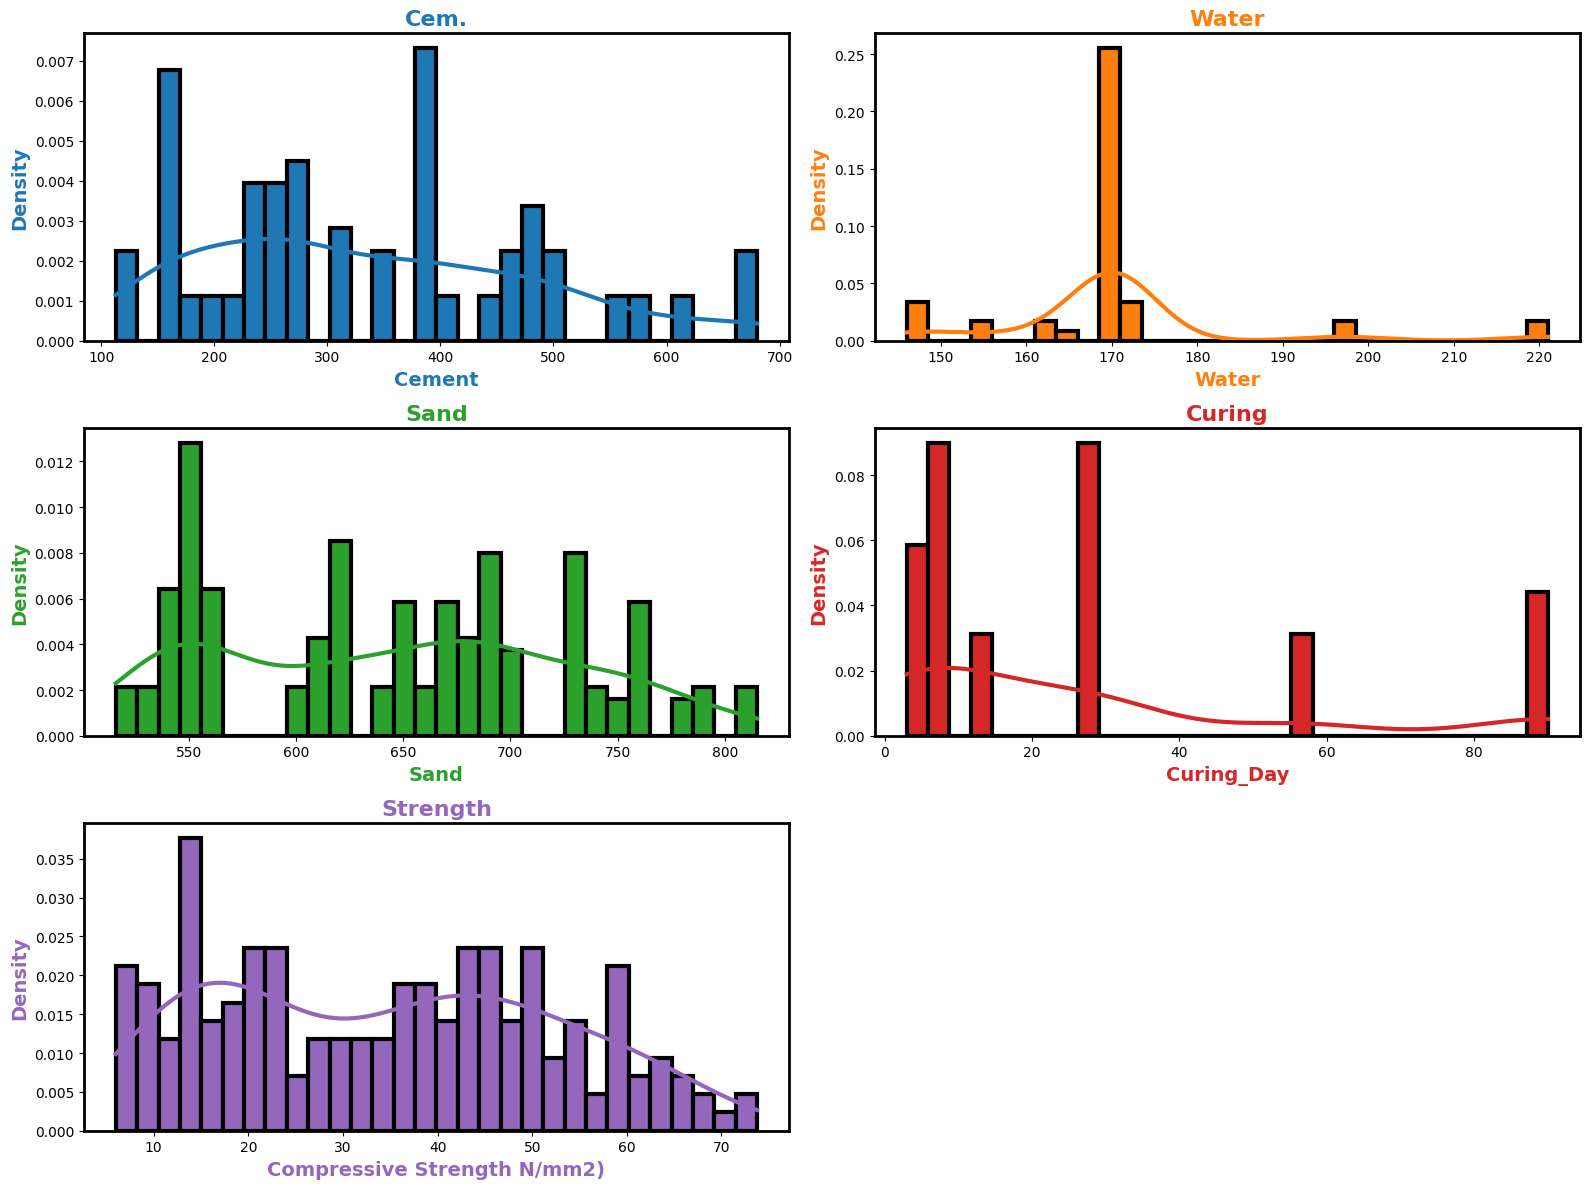

In [85]:
# 1. Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Select the relevant columns for plotting from compressive_data
# Choosing a few numerical columns for demonstration
features_to_plot = ['Cement', 'Water', 'Sand', 'Curing_Day', 'Compressive Strength N/mm2)']

# Abbreviations for each parameter (adjust if needed)
abbreviations = ['Cem.', 'Water', 'Sand', 'Curing', 'Strength']


# 3. Set up the plotting environment with a larger figure size for better visibility
plt.figure(figsize=(16, 12))

# 4. Bold colors for each plot (use more vibrant colors)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] # Adjust number of colors

# 5. Loop through each feature to plot histograms and probability density functions (PDF)
for i, (feature, abbr) in enumerate(zip(features_to_plot, abbreviations), 1):
    plt.subplot(3, 2, i)  # Adjust grid size based on number of features
    # Use linewidth=3 for bolder KDE contour lines and bolder histogram edges
    sns.histplot(compressive_data[feature], kde=True, bins=30, color=colors[i-1], stat='density', linewidth=3, alpha=1.0)

    # Get the current axes and plot the KDE line with bolder contour lines
    ax = plt.gca()
    for line in ax.lines:
        line.set_linewidth(3)  # Make KDE contour lines bolder

    # Title, xlabel, and ylabel with bold font
    plt.title(f'{abbr}', fontsize=16, fontweight='bold', color=colors[i-1])
    plt.xlabel(feature, fontsize=14, fontweight='bold', color=colors[i-1])
    plt.ylabel('Density', fontsize=14, fontweight='bold', color=colors[i-1])
    plt.grid(False)  # Remove gridlines

    # Make all the borders of the plot bold
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # Set the border width (2 is for bold borders)
        spine.set_edgecolor('black')  # Make the borders black for visibility

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [86]:
import pandas as pd
import scipy.stats as stats

# Assuming the features in compressive_data are the ones you want to characterize
# List of features from the compressive_data DataFrame
features = compressive_data.columns.tolist()

# Remove the target variable if it's in the features list
if 'Compressive Strength N/mm2)' in features:
    features.remove('Compressive Strength N/mm2)')

# Calculate basic statistics
desc_stats = compressive_data[features].describe().T  # Transpose for better readability

# Adding skewness and kurtosis to the description
desc_stats['Skewness'] = compressive_data[features].skew()
desc_stats['Kurtosis'] = compressive_data[features].kurt()

# Adding percentiles (25%, 50%, 75%)
desc_stats['25%'] = compressive_data[features].quantile(0.25)
desc_stats['50%'] = compressive_data[features].quantile(0.50)  # Median
desc_stats['75%'] = compressive_data[features].quantile(0.75)

# Rearranging the columns for desired output format
desc_stats = desc_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'Skewness', 'Kurtosis']]

# Rename the columns for clarity
desc_stats.columns = ['Count', 'Mean', 'Std', 'Min', '25%', 'Median', '75%', 'Max', 'Skewness', 'Kurtosis']

# Display the table
print("Statistical Characterization of the Dataset:")
print(desc_stats)

Statistical Characterization of the Dataset:
                          Count           Mean           Std      Min  \
Cement                    188.0     338.574468    146.911774    113.0   
Flyash                    188.0      50.000000    101.264730      0.0   
GGBS                      188.0      60.021277    113.019328      0.0   
MK                        188.0      11.446809     26.732830      0.0   
Water                     188.0     170.446809     14.172065    146.0   
SP                        188.0       2.506218      2.303849      0.0   
VMA                       188.0       0.334043      0.496071      0.0   
NCA_20                    188.0      37.452128    143.861278      0.0   
NCA_10                    188.0      37.053191    142.330366      0.0   
RCA_20                    188.0     387.063830    126.338338      0.0   
RCA_10                    188.0     484.457447    147.473240      0.0   
Sand                      188.0     646.563830     80.977657    516.0   
Curing

In [87]:
import shap
import xgboost as xgb
import pandas as pd

# Use the features (X) and target (y) from compressive_data
# Train the XGBoost model using the data from compressive_data
# We will use the best parameters found during grid search in cell eIeODRGbZP9P
best_params = {'learning_rate': 0.05, 'max_depth': 20, 'n_estimators': 150, 'subsample': 0.8}
model = xgb.XGBRegressor(objective='reg:squarederror', **best_params, random_state=42)
model.fit(X, y)

# Create a SHAP explainer using the trained model and the features (X)
explainer = shap.Explainer(model, X)

# Calculate SHAP values
# Note: This might take some time depending on the size of your dataset and model complexity.
shap_values = explainer(X)

# Extract the absolute mean SHAP values
shap_importance = abs(shap_values.values).mean(axis=0)

# Create a dataframe to display feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean Absolute SHAP Value': shap_importance
})

# Sort the dataframe by mean absolute SHAP value in descending order
importance_df = importance_df.sort_values(by='Mean Absolute SHAP Value', ascending=False)

# Display the table
print(importance_df)

                     Feature  Mean Absolute SHAP Value
12                Curing_Day                  7.348434
5                         SP                  4.702984
0                     Cement                  3.639203
13  Cement_Water_Interaction                  1.943780
1                     Flyash                  1.791169
10                    RCA_10                  1.703336
2                       GGBS                  1.618828
21   Cement_Sand_Interaction                  1.000769
9                     RCA_20                  0.607748
4                      Water                  0.479632
3                         MK                  0.305897
11                      Sand                  0.295166
22   Flyash_Sand_Interaction                  0.136349
17      SP_Water_Interaction                  0.088145
6                        VMA                  0.048284
18     VMA_Water_Interaction                  0.047124
14  Flyash_Water_Interaction                  0.003911
7         

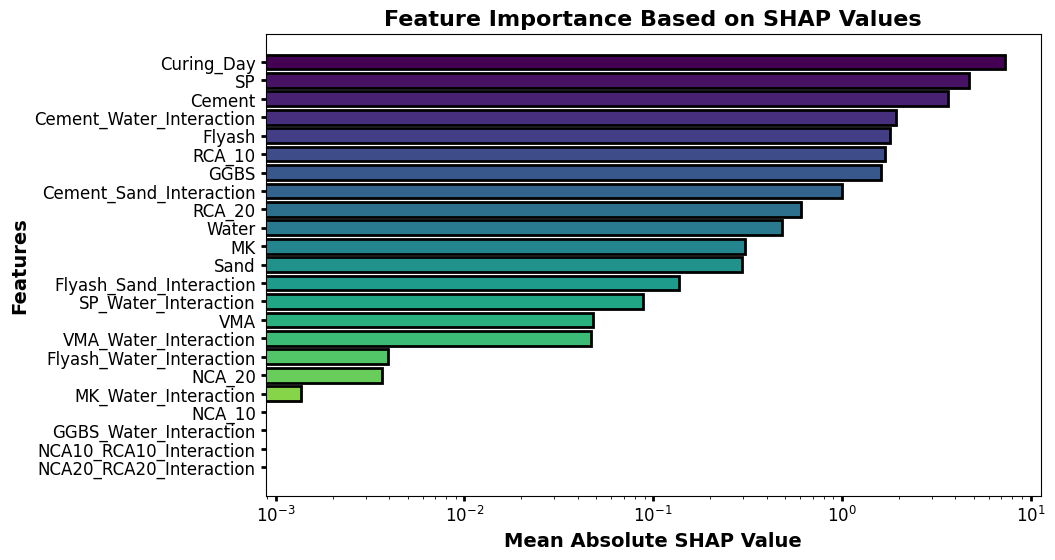

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# Extract features and importance values from the DataFrame
features = importance_df['Feature'].tolist()
importance_values = importance_df['Mean Absolute SHAP Value'].values

# Create the bar chart with a log scale on the x-axis
plt.figure(figsize=(10, 6))

# Apply a colormap to the bars
colors = plt.cm.viridis(np.linspace(0, 1, len(importance_values)))

# Plot the bars
bars = plt.barh(features, importance_values, color=colors, edgecolor='black', linewidth=2)

# Set the x-axis to log scale
plt.xscale('log')

# Customize the plot
plt.xlabel('Mean Absolute SHAP Value', fontsize=14, weight='bold')
plt.ylabel('Features', fontsize=14, weight='bold')
plt.title('Feature Importance Based on SHAP Values', fontsize=16, weight='bold')

# Bold the lines of the axes
plt.tick_params(axis='both', which='major', labelsize=12, width=2)

# Invert the y-axis so that the most important feature is on top
plt.gca().invert_yaxis()

# Show the plot
plt.show()

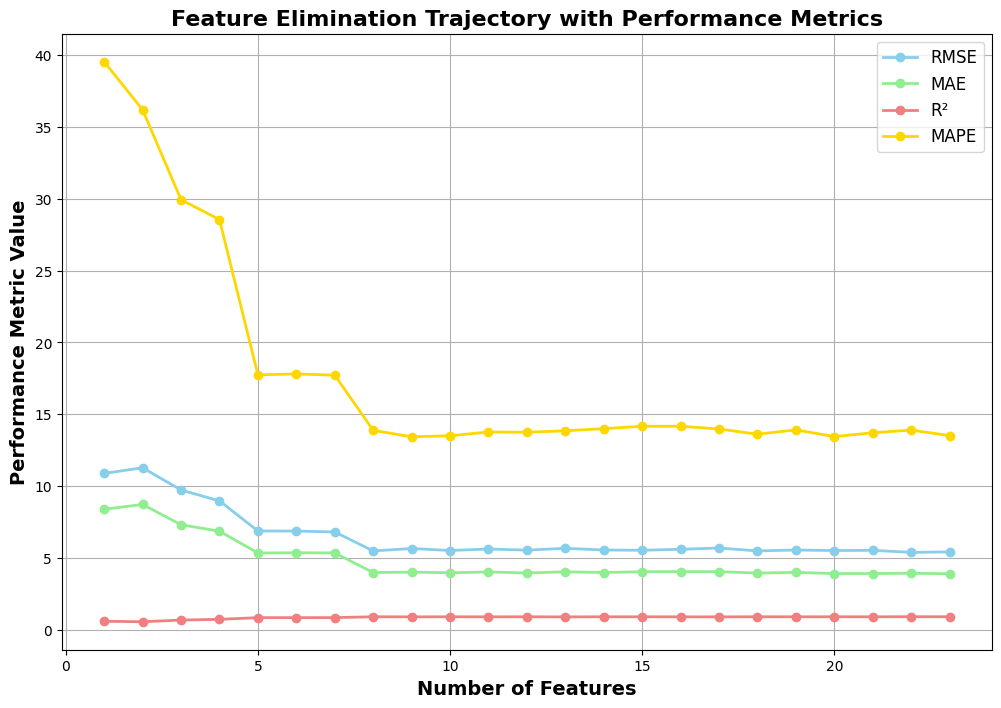

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE  # Use RFE instead of SFS for faster feature elimination
import math

# Use the compressive_data
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Lists to store metrics
rmse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []

# Use RFE for feature selection instead of SFS (faster)
rfe = RFE(model)

# Loop over number of features (from all to 1)
for n_features in range(X_train.shape[1], 0, -1):
    # Perform RFE for current number of features
    rfe.n_features_to_select = n_features
    rfe.fit(X_train, y_train)

    selected_features = rfe.get_support(indices=True)
    X_train_selected = X_train.iloc[:, selected_features]
    X_test_selected = X_test.iloc[:, selected_features]

    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)

    # Compute performance metrics
    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    # Add a small epsilon to y_test to avoid division by zero in MAPE
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100
    r2 = r2_score(y_test, y_pred)


    # Append metrics
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)

# Reverse the lists to plot from 1 feature to all features
rmse_scores.reverse()
mae_scores.reverse()
r2_scores.reverse()
mape_scores.reverse()

# Create the plot with all metrics
plt.figure(figsize=(12, 8))
features_range = range(1, X_train.shape[1] + 1)  # Number of features at each step

plt.plot(features_range, rmse_scores, marker='o', label='RMSE', color='skyblue', linewidth=2)
plt.plot(features_range, mae_scores, marker='o', label='MAE', color='lightgreen', linewidth=2)
plt.plot(features_range, r2_scores, marker='o', label='R²', color='lightcoral', linewidth=2)
plt.plot(features_range, mape_scores, marker='o', label='MAPE', color='gold', linewidth=2)

plt.xlabel('Number of Features', fontsize=14, weight='bold')
plt.ylabel('Performance Metric Value', fontsize=14, weight='bold')
plt.title('Feature Elimination Trajectory with Performance Metrics', fontsize=16, weight='bold')
plt.legend(loc='best', fontsize=12)
plt.grid(True)
plt.show()

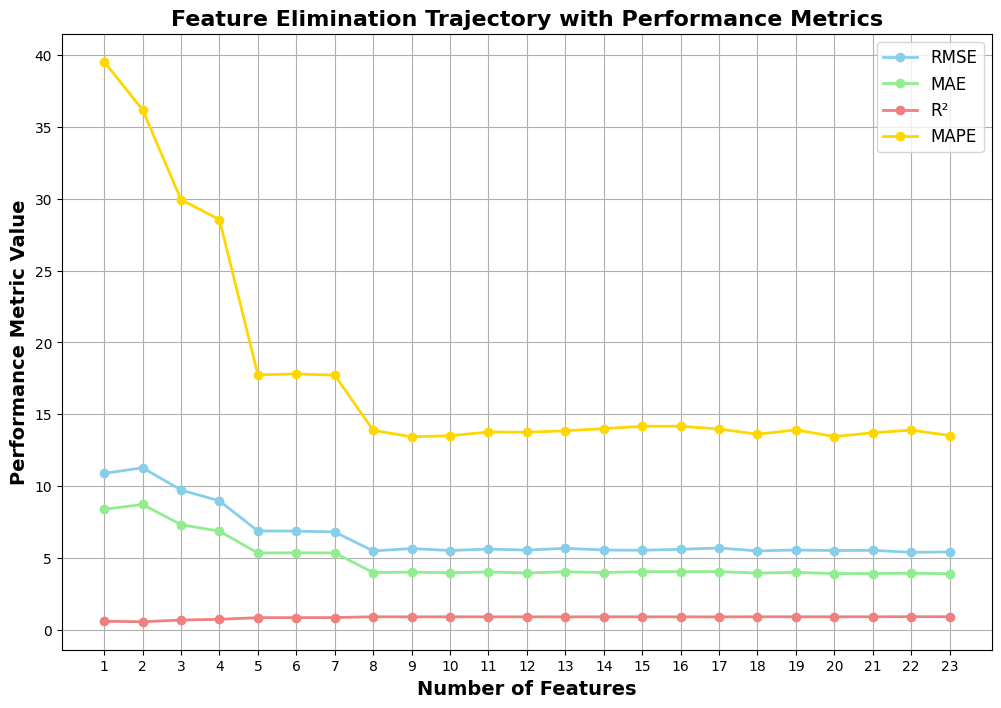

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE  # Use RFE instead of SFS for faster feature elimination
import math

# Use the compressive_data
# Example dataset (update to use compressive_data)
X = compressive_data.drop(columns=['Compressive Strength N/mm2)']) # Drop the target variable
y = compressive_data['Compressive Strength N/mm2)']

# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Lists to store metrics
rmse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []

# Get feature names for plotting
feature_names = X_train.columns

# Use RFE for feature selection instead of SFS (faster)
rfe = RFE(model)

# Loop over number of features (from all to 1)
for n_features in range(X_train.shape[1], 0, -1):
    # Perform RFE for current number of features
    rfe.n_features_to_select = n_features
    rfe.fit(X_train, y_train)

    selected_features = rfe.get_support(indices=True)
    X_train_selected = X_train.iloc[:, selected_features]
    X_test_selected = X_test.iloc[:, selected_features]

    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)

    # Compute performance metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    # Add a small epsilon to y_test to avoid division by zero in MAPE
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100
    r2 = r2_score(y_test, y_pred)

    # Append metrics
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)

# Reverse the lists to plot from 1 feature to all features
rmse_scores.reverse()
mae_scores.reverse()
r2_scores.reverse()
mape_scores.reverse()

# Create the plot with all metrics
plt.figure(figsize=(12, 8))
# Use the number of features for the x-axis since feature names are too long
features_range = range(1, X_train.shape[1] + 1)

# Plot each performance metric
plt.plot(features_range, rmse_scores, marker='o', label='RMSE', color='skyblue', linewidth=2)
plt.plot(features_range, mae_scores, marker='o', label='MAE', color='lightgreen', linewidth=2)
plt.plot(features_range, r2_scores, marker='o', label='R²', color='lightcoral', linewidth=2)
plt.plot(features_range, mape_scores, marker='o', label='MAPE', color='gold', linewidth=2)

# Customize the plot
plt.xlabel('Number of Features', fontsize=14, weight='bold')
plt.ylabel('Performance Metric Value', fontsize=14, weight='bold')
plt.title('Feature Elimination Trajectory with Performance Metrics', fontsize=16, weight='bold')
plt.legend(loc='best', fontsize=12)
# Use the number of features for ticks
plt.xticks(features_range)
plt.grid(True)  # Show gridlines for better readability

# Show the plot
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.224e+03, tolerance: 4.940e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.224e+03, tolerance: 4.940e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.224e+03, tolerance: 4.940e

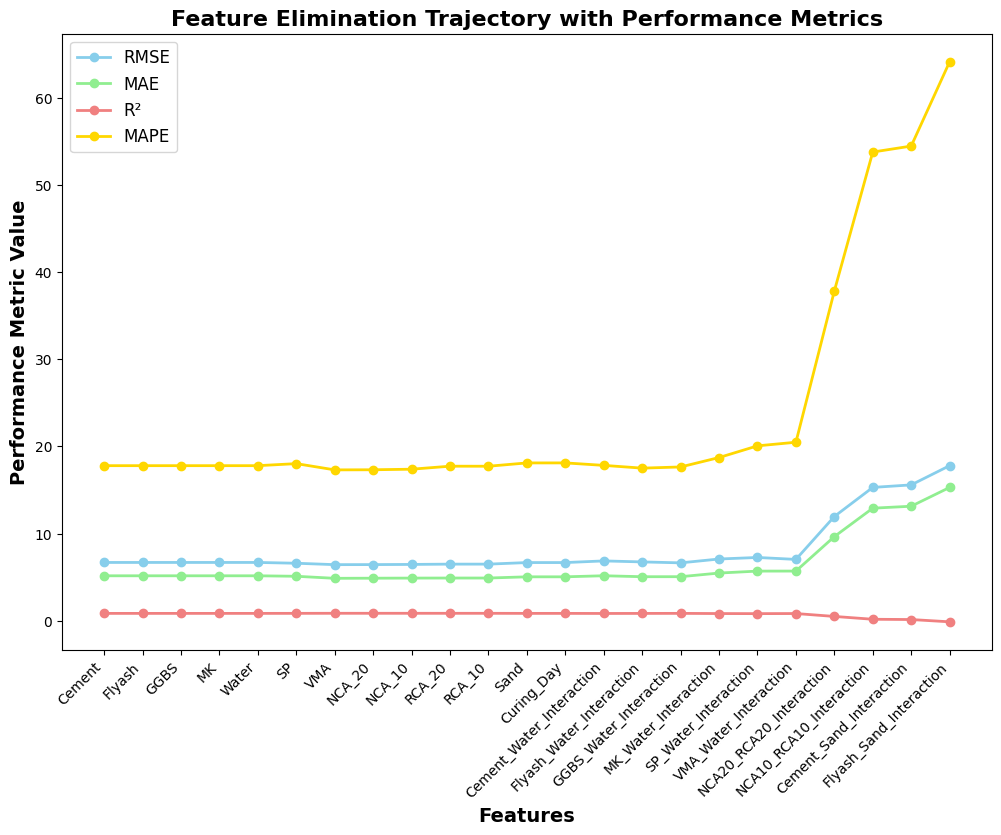

Cross-validated R²: 0.776872566849484
Cross-validated RMSE: 8.051916661426858


In [91]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Lasso  # Use Lasso regression (L1 regularization)
from sklearn.feature_selection import RFE

# Example dataset
X = compressive_data.drop(columns=['Compressive Strength N/mm2)']) # Drop the target variable
y = compressive_data['Compressive Strength N/mm2)']
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Lasso model with L1 regularization
model = Lasso(alpha=0.1)  # Adjust alpha for stronger/weak regularization

# Lists to store metrics
rmse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []

# Get feature names for plotting
feature_names = X_train.columns

# Use RFE for feature selection
rfe = RFE(model)

# Loop over number of features (from all to 1)
for n_features in range(X_train.shape[1], 0, -1):
    # Perform RFE for current number of features
    rfe.n_features_to_select = n_features
    rfe.fit(X_train, y_train)

    selected_features = rfe.get_support(indices=True)
    X_train_selected = X_train.iloc[:, selected_features]
    X_test_selected = X_test.iloc[:, selected_features]

    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)

    # Compute performance metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    # Append metrics
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)

# Perform Cross-validation
cross_val_r2 = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
cross_val_rmse = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

# Create the plot with all metrics
plt.figure(figsize=(12, 8))
features_range = feature_names[:len(rfe.support_)]  # Feature names for each step

# Plot each performance metric
plt.plot(features_range, rmse_scores, marker='o', label='RMSE', color='skyblue', linewidth=2)
plt.plot(features_range, mae_scores, marker='o', label='MAE', color='lightgreen', linewidth=2)
plt.plot(features_range, r2_scores, marker='o', label='R²', color='lightcoral', linewidth=2)
plt.plot(features_range, mape_scores, marker='o', label='MAPE', color='gold', linewidth=2)

# Customize the plot
plt.xlabel('Features', fontsize=14, weight='bold')
plt.ylabel('Performance Metric Value', fontsize=14, weight='bold')
plt.title('Feature Elimination Trajectory with Performance Metrics', fontsize=16, weight='bold')
plt.legend(loc='best', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate feature names for readability
plt.grid(False)  # Remove gridlines

# Show the plot
plt.show()

# Print cross-validation results
print("Cross-validated R²:", cross_val_r2.mean())
print("Cross-validated RMSE:", -cross_val_rmse.mean())  # RMSE is negative in cross_val_score

In [92]:
import pandas as pd

# Example ranked features (replace with your actual list)
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
       'Cement_Water_Interaction', 'Flyash_Water_Interaction',
       'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]


# Define your subsets
feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],   # Adjust to make S3 different from S7
    'S4': ranked_features[:5],
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,       # All features
    'S8': ranked_features[:6],
}

# Create table
table_data = []
for subset, features in feature_subsets.items():
    feature_str = ', '.join(features)
    feature_count = len(features)
    table_data.append([subset, feature_str, feature_count])

df_table = pd.DataFrame(table_data, columns=['Dataset', 'Feature Variables', 'Feature Number'])

# Display the table
print(df_table.to_string(index=False))


Dataset                                                                                                                                         Feature Variables  Feature Number
     S1                                                                                                                          Cement, Flyash, GGBS, Water, VMA               5
     S2                                                                                                    Cement, Flyash, GGBS, Water, VMA, RCA_20, RCA_10, Sand               8
     S3                                                                          Cement, Flyash, GGBS, Water, VMA, RCA_20, RCA_10, Sand, Cement_Water_Interaction               9
     S4                                                                                                                          Cement, Flyash, GGBS, Water, VMA               5
     S5                                                                                                       

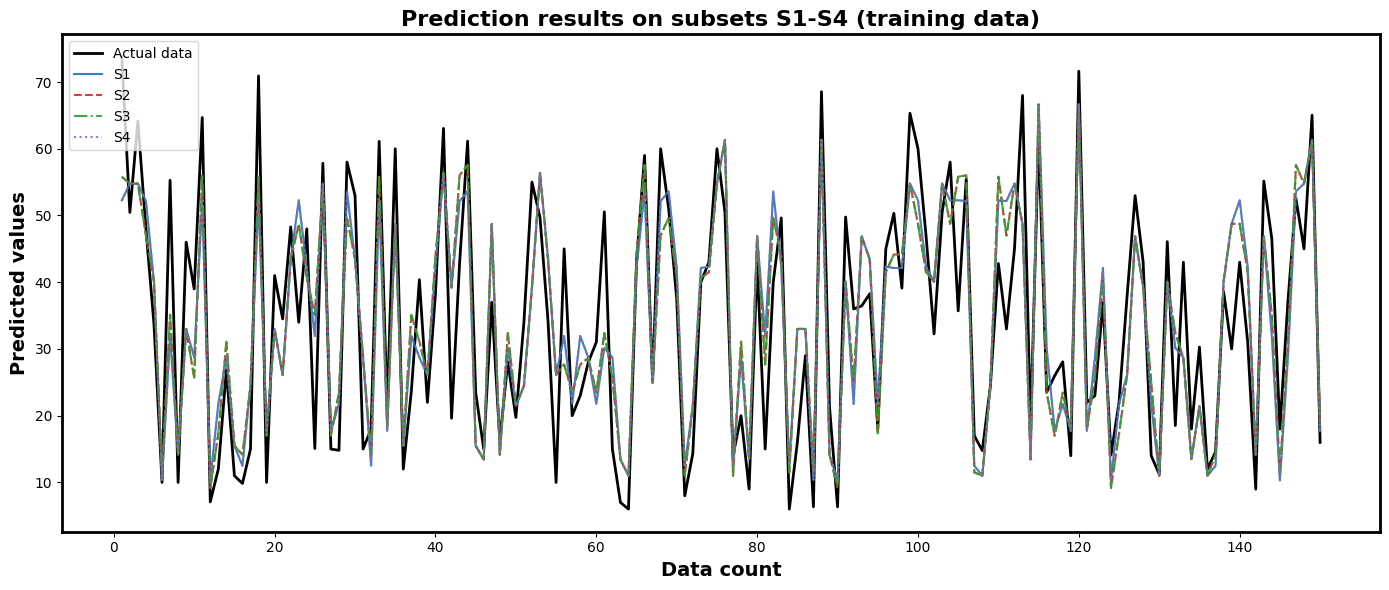

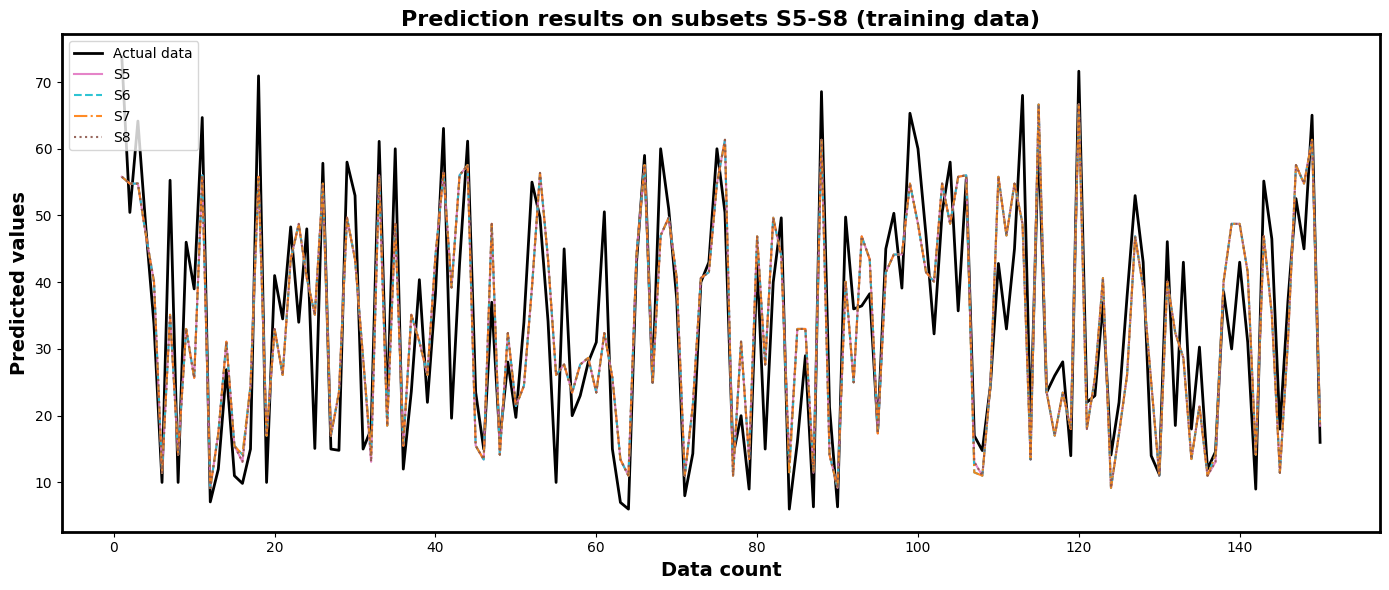

In [93]:
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assume X, y, X_train, y_train are already defined from previous cells (iBlYDzdGXBoi and HIPv-AwMpU4h)

# Define ranked features as they were in the deleted cell mk9I6DMIyeov (and W0eIwmYTi4D2)
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
   'Cement_Water_Interaction', 'Flyash_Water_Interaction',
   'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]

# Define feature subsets (as in W0eIwmYTi4D2)
feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],
    'S4': ranked_features[:5],
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,
    'S8': ranked_features[:6],
}

# Train model on each subset + store predictions for the TRAINING set
predictions = {}

for subset_name, features in feature_subsets.items():
    # Select features from the training data
    X_subset_train = X_train[features]
    model = xgb.XGBRegressor(objective='reg:squarederror')
    model.fit(X_subset_train, y_train)
    # Predict on the training subset
    y_pred_train = model.predict(X_subset_train)
    predictions[subset_name] = y_pred_train

# Plot S1-S4 with colored lines + different styles
plt.figure(figsize=(14, 6))
plt.plot(range(1, len(y_train)+1), y_train, 'k-', linewidth=2, label='Actual data')

colors_s1_s4 = {'S1': '#1f77b4', 'S2': '#d62728', 'S3': '#2ca02c', 'S4': '#9467bd'}
styles_s1_s4 = {'S1': '-', 'S2': '--', 'S3': '-.', 'S4': ':'}
for subset in ['S1', 'S2', 'S3', 'S4']:
    plt.plot(range(1, len(y_train)+1), predictions[subset],
             color=colors_s1_s4[subset], linestyle=styles_s1_s4[subset], linewidth=1.5, alpha=0.9, label=subset)

plt.xlabel('Data count', fontsize=14, weight='bold')
plt.ylabel('Predicted values', fontsize=14, weight='bold')
plt.title('Prediction results on subsets S1-S4 (training data)', fontsize=16, weight='bold')
plt.legend()

# Bold plot border lines
for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

plt.grid(False)
plt.tight_layout()
plt.show()

# Plot S5-S8 with colored lines + different styles
plt.figure(figsize=(14, 6))
plt.plot(range(1, len(y_train)+1), y_train, 'k-', linewidth=2, label='Actual data')

colors_s5_s8 = {'S5': '#e377c2', 'S6': '#17becf', 'S7': '#ff7f0e', 'S8': '#8c564b'}
styles_s5_s8 = {'S5': '-', 'S6': '--', 'S7': '-.', 'S8': ':'}
for subset in ['S5', 'S6', 'S7', 'S8']:
    plt.plot(range(1, len(y_train)+1), predictions[subset],
             color=colors_s5_s8[subset], linestyle=styles_s5_s8[subset], linewidth=1.5, alpha=0.9, label=subset)

plt.xlabel('Data count', fontsize=14, weight='bold')
plt.ylabel('Predicted values', fontsize=14, weight='bold')
plt.title('Prediction results on subsets S5-S8 (training data)', fontsize=16, weight='bold')
plt.legend()

# Bold plot border lines
for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

plt.grid(False)
plt.tight_layout()
plt.show()

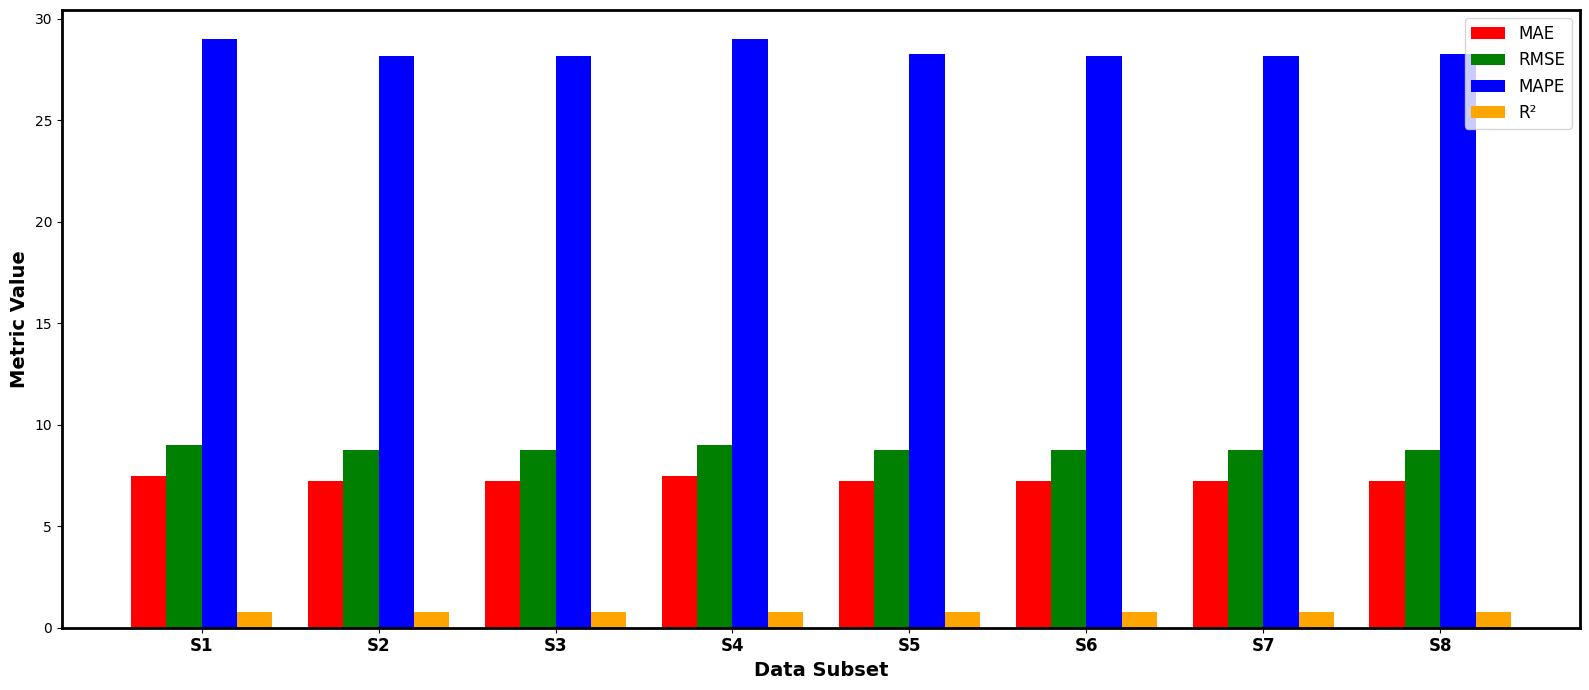

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ✅ Metric evaluation bar chart (ALL DATA)
mae_scores, rmse_scores, mape_scores, r2_scores = [], [], [], []

for subset in feature_subsets.keys():
    y_pred = predictions[subset]
    mae = mean_absolute_error(y_train, y_pred)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    mape = np.mean(np.abs((y_train - y_pred) / y_train)) * 100
    r2 = r2_score(y_train, y_pred)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    mape_scores.append(mape)
    r2_scores.append(r2)

x = np.arange(len(feature_subsets))
width = 0.2

plt.figure(figsize=(16, 7))
plt.bar(x - 1.5*width, mae_scores, width, label='MAE', color='red')
plt.bar(x - 0.5*width, rmse_scores, width, label='RMSE', color='green')
plt.bar(x + 0.5*width, mape_scores, width, label='MAPE', color='blue')
plt.bar(x + 1.5*width, r2_scores, width, label='R²', color='orange')

plt.xticks(x, feature_subsets.keys(), fontsize=12, weight='bold')
plt.xlabel('Data Subset', fontsize=14, weight='bold')
plt.ylabel('Metric Value', fontsize=14, weight='bold')
plt.legend(fontsize=12, loc='upper right')
for spine in plt.gca().spines.values():
    spine.set_linewidth(2)
plt.grid(False)
plt.tight_layout()
plt.show()

In [95]:
print(f"\nNumber of samples in y_train (actual): {len(y_train)}")
for subset in feature_subsets.keys():
    print(f"Subset {subset}: predicted samples = {len(predictions[subset])}")


Number of samples in y_train (actual): 150
Subset S1: predicted samples = 150
Subset S2: predicted samples = 150
Subset S3: predicted samples = 150
Subset S4: predicted samples = 150
Subset S5: predicted samples = 150
Subset S6: predicted samples = 150
Subset S7: predicted samples = 150
Subset S8: predicted samples = 150


In [96]:
print("\nFirst few actual and predicted pairs for S1:")
print(pd.DataFrame({
    "Actual": y_train.head(5).values,
    "Predicted": predictions['S1'][:5]
}))


First few actual and predicted pairs for S1:
   Actual  Predicted
0   73.76  52.274570
1   50.46  54.777542
2   64.15  54.777542
3   48.00  52.158524
4   33.69  40.080475


In [97]:
# ✅ Create a metrics table with Pandas DataFrame
metrics_table = pd.DataFrame({
    'Subset': list(feature_subsets.keys()),
    'MAE': mae_scores,
    'RMSE': rmse_scores,
    'MAPE (%)': mape_scores,
    'R²': r2_scores
})

# ✅ Round metrics for clarity
metrics_table = metrics_table.round({'MAE': 4, 'RMSE': 4, 'MAPE (%)': 4, 'R²': 6})

# ✅ Display the table
print("\nMetrics Evaluation Table:")
print(metrics_table.to_string(index=False))



Metrics Evaluation Table:
Subset    MAE   RMSE  MAPE (%)       R²
    S1 7.4513 9.0089   28.9765 0.753579
    S2 7.2282 8.7523   28.1434 0.767419
    S3 7.2282 8.7523   28.1433 0.767419
    S4 7.4513 9.0089   28.9765 0.753579
    S5 7.2353 8.7555   28.2735 0.767249
    S6 7.2282 8.7523   28.1433 0.767419
    S7 7.2282 8.7523   28.1433 0.767419
    S8 7.2353 8.7555   28.2734 0.767249


In [98]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming X_train, y_train, and feature_subsets are defined in previous cells.
# Re-defining ranked_features and feature_subsets for self-containment
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
   'Cement_Water_Interaction', 'Flyash_Water_Interaction',
   'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]

feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],
    'S4': ranked_features[:5], # Duplicated S1, as per original notebook
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,      # All features
    'S8': ranked_features[:6],
}

# Dictionaries to store predictions and lists to store metrics for each subset
predictions_rf = {}
mae_scores = []
rmse_scores = []
mape_scores = []
r2_scores = []
subset_names = []

# Train RandomForestRegressor for each feature subset
for subset_name, features in feature_subsets.items():
    print(f"Training Random Forest on subset: {subset_name} with features: {features}")

    # Select features for the current subset from the training data
    X_subset_train = X_train[features]

    # Train optimized Random Forest
    rf = RandomForestRegressor(
        n_estimators=332, max_features=5, max_depth=24,
        min_samples_split=5, min_samples_leaf=1, random_state=42 # Added random_state for reproducibility
    )
    rf.fit(X_subset_train, y_train)

    # Make predictions on the training data using the subset
    y_pred = rf.predict(X_subset_train)
    predictions_rf[subset_name] = y_pred

    # Compute performance metrics
    mae = mean_absolute_error(y_train, y_pred)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    # Handle division by zero in MAPE
    mape = np.mean(np.abs((y_train - y_pred) / (y_train + 1e-8))) * 100
    r2 = r2_score(y_train, y_pred)

    # Append metrics and subset name
    subset_names.append(subset_name)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    mape_scores.append(mape)
    r2_scores.append(r2)

# Create a DataFrame for the metrics
df_metrics = pd.DataFrame({
    'Model': [f'RF_{name}' for name in subset_names], # Prefix with RF to distinguish
    'MAE': mae_scores,
    'RMSE': rmse_scores,
    'MAPE (%)': mape_scores,
    'R²': r2_scores
}).round(6)

# Save the metrics to a CSV file
df_metrics.to_csv('metrics_RF_subsets.csv', index=False)

print("\nRandom Forest Metrics for each subset:")
print(df_metrics.to_string(index=False))

# You can also save predictions for each subset if needed, for example:
# for subset_name, y_pred_values in predictions_rf.items():
#     pd.DataFrame({'Actual': y_train, 'Predicted': y_pred_values}).to_csv(f'predictions_RF_{subset_name}.csv', index=False)


Training Random Forest on subset: S1 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training Random Forest on subset: S2 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand']
Training Random Forest on subset: S3 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction']
Training Random Forest on subset: S4 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training Random Forest on subset: S5 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10']
Training Random Forest on subset: S6 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction']
Training Random Forest on subset: S7 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction', 'GGBS_Water_Interaction', 'VMA_Water_Interaction'

In [99]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Assuming X_train, y_train, and feature_subsets are defined in previous cells.

# Lists to store metrics for each subset
mae_scores = []
rmse_scores = []
mape_scores = []
r2_scores = []
subset_names = []

# Train DummyRegressor for each feature subset
for subset_name, features in feature_subsets.items():
    print(f"Training Dummy Regressor on subset: {subset_name} with features: {features}")

    # Select features for the current subset from the training data
    # DummyRegressor does not use X for prediction with strategy='mean',
    # but we pass it for consistent API with other models.
    X_subset_train = X_train[features]

    # Initialize Dummy Regressor model
    dummy = DummyRegressor(strategy='mean')

    # Train the model on the training data for the current subset
    dummy.fit(X_subset_train, y_train)

    # Make predictions on the training data (for evaluation consistency)
    y_pred = dummy.predict(X_subset_train)

    # Compute performance metrics
    mae = mean_absolute_error(y_train, y_pred)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    # Handle division by zero in MAPE
    mape = np.mean(np.abs((y_train - y_pred) / (y_train + 1e-8))) * 100
    r2 = r2_score(y_train, y_pred)

    # Append metrics and subset name
    subset_names.append(subset_name)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    mape_scores.append(mape)
    r2_scores.append(r2)

# Create a DataFrame for the metrics
df_metrics_dummy_subsets = pd.DataFrame({
    'Model': [f'Dummy_{name}' for name in subset_names],
    'MAE': mae_scores,
    'RMSE': rmse_scores,
    'MAPE (%)': mape_scores,
    'R²': r2_scores
}).round(6)

# Save the metrics to a CSV file
df_metrics_dummy_subsets.to_csv('metrics_Dummy_subsets.csv', index=False)

print("\nDummy Regressor Metrics for each subset:")
print(df_metrics_dummy_subsets.to_string(index=False))


Training Dummy Regressor on subset: S1 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training Dummy Regressor on subset: S2 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand']
Training Dummy Regressor on subset: S3 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction']
Training Dummy Regressor on subset: S4 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training Dummy Regressor on subset: S5 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10']
Training Dummy Regressor on subset: S6 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction']
Training Dummy Regressor on subset: S7 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction', 'GGBS_Water_Interaction', 'VMA_Wate

In [100]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Assuming X_train, y_train, and feature_subsets are defined in previous cells.
# Re-defining ranked_features and feature_subsets for self-containment
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
   'Cement_Water_Interaction', 'Flyash_Water_Interaction',
   'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]

feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],
    'S4': ranked_features[:5],
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,      # All features
    'S8': ranked_features[:6],
}

# Lists to store metrics for each subset
mae_scores = []
rmse_scores = []
mape_scores = []
r2_scores = []
subset_names = []

# Train LinearRegression for each feature subset
for subset_name, features in feature_subsets.items():
    print(f"Training Linear Regression on subset: {subset_name} with features: {features}")

    # Select features for the current subset from the training data
    X_subset_train = X_train[features]

    # Initialize Linear Regression model
    lr = LinearRegression()

    # Train the model on the training data for the current subset
    lr.fit(X_subset_train, y_train)

    # Make predictions on the training data (for evaluation consistency)
    y_pred = lr.predict(X_subset_train)

    # Compute performance metrics
    mae = mean_absolute_error(y_train, y_pred)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    # Handle division by zero in MAPE
    mape = np.mean(np.abs((y_train - y_pred) / (y_train + 1e-8))) * 100
    r2 = r2_score(y_train, y_pred)

    # Append metrics and subset name
    subset_names.append(subset_name)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    mape_scores.append(mape)
    r2_scores.append(r2)

# Create a DataFrame for the metrics
df_metrics_linear_subsets = pd.DataFrame({
    'Model': [f'Linear_{name}' for name in subset_names],
    'MAE': mae_scores,
    'RMSE': rmse_scores,
    'MAPE (%)': mape_scores,
    'R²': r2_scores
}).round(6)

# Save the metrics to a CSV file
df_metrics_linear_subsets.to_csv('metrics_Linear_subsets.csv', index=False)

print("\nLinear Regression Metrics for each subset:")
print(df_metrics_linear_subsets.to_string(index=False))


Training Linear Regression on subset: S1 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training Linear Regression on subset: S2 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand']
Training Linear Regression on subset: S3 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction']
Training Linear Regression on subset: S4 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training Linear Regression on subset: S5 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10']
Training Linear Regression on subset: S6 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction']
Training Linear Regression on subset: S7 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction', 'GGBS_Water_Interacti

In [101]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Assuming X_train, y_train, and feature_subsets are defined in previous cells.
# Re-defining ranked_features and feature_subsets for self-containment
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
   'Cement_Water_Interaction', 'Flyash_Water_Interaction',
   'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]

feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],
    'S4': ranked_features[:5],
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,      # All features
    'S8': ranked_features[:6],
}

# Lists to store metrics for each subset
mae_scores = []
rmse_scores = []
mape_scores = []
r2_scores = []
subset_names = []

# Train DecisionTreeRegressor for each feature subset
for subset_name, features in feature_subsets.items():
    print(f"Training Decision Tree on subset: {subset_name} with features: {features}")

    # Select features for the current subset from the training data
    X_subset_train = X_train[features]

    # Initialize Decision Tree Regressor model with max_depth=6 for better performance
    tree = DecisionTreeRegressor(max_depth=6, random_state=42)

    # Train the model on the training data for the current subset
    tree.fit(X_subset_train, y_train)

    # Make predictions on the training data (for evaluation consistency)
    y_pred = tree.predict(X_subset_train)

    # Compute performance metrics
    mae = mean_absolute_error(y_train, y_pred)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    # Handle division by zero in MAPE
    mape = np.mean(np.abs((y_train - y_pred) / (y_train + 1e-8))) * 100
    r2 = r2_score(y_train, y_pred)

    # Append metrics and subset name
    subset_names.append(subset_name)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    mape_scores.append(mape)
    r2_scores.append(r2)

# Create a DataFrame for the metrics
df_metrics_tree_subsets = pd.DataFrame({
    'Model': [f'DecisionTree_{name}' for name in subset_names],
    'MAE': mae_scores,
    'RMSE': rmse_scores,
    'MAPE (%)': mape_scores,
    'R²': r2_scores
}).round(6)

# Save the metrics to a CSV file
df_metrics_tree_subsets.to_csv('metrics_DecisionTree_subsets.csv', index=False)

print("\nDecision Tree Regressor Metrics for each subset:")
print(df_metrics_tree_subsets.to_string(index=False))


Training Decision Tree on subset: S1 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training Decision Tree on subset: S2 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand']
Training Decision Tree on subset: S3 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction']
Training Decision Tree on subset: S4 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training Decision Tree on subset: S5 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10']
Training Decision Tree on subset: S6 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction']
Training Decision Tree on subset: S7 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction', 'GGBS_Water_Interaction', 'VMA_Water_Interaction'

In [102]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming X_train, y_train, and feature_subsets are defined in previous cells.
# Re-defining ranked_features and feature_subsets for self-containment
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
   'Cement_Water_Interaction', 'Flyash_Water_Interaction',
   'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]

feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],
    'S4': ranked_features[:5],
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,      # All features
    'S8': ranked_features[:6],
}

# Lists to store metrics for each subset
predictions_knn = {}
mae_scores = []
rmse_scores = []
mape_scores = []
r2_scores = []
subset_names = []

# Train KNeighborsRegressor for each feature subset
for subset_name, features in feature_subsets.items():
    print(f"Training K-Neighbors Regressor on subset: {subset_name} with features: {features}")

    # Select features for the current subset from the training data
    X_subset_train = X_train[features]

    # Initialize K-Neighbors Regressor model (keeping n_neighbors=1 as in original, 'intentionally bad')
    knn = KNeighborsRegressor(n_neighbors=1)

    # Train the model on the training data for the current subset
    knn.fit(X_subset_train, y_train)

    # Make predictions on the training data (for evaluation consistency)
    y_pred = knn.predict(X_subset_train)
    predictions_knn[subset_name] = y_pred

    # Compute performance metrics
    mae = mean_absolute_error(y_train, y_pred)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    # Handle division by zero in MAPE
    mape = np.mean(np.abs((y_train - y_pred) / (y_train + 1e-8))) * 100
    r2 = r2_score(y_train, y_pred)

    # Append metrics and subset name
    subset_names.append(subset_name)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    mape_scores.append(mape)
    r2_scores.append(r2)

# Create a DataFrame for the metrics
df_metrics = pd.DataFrame({
    'Model': [f'KNN_{name}' for name in subset_names],
    'MAE': mae_scores,
    'RMSE': rmse_scores,
    'MAPE (%)': mape_scores,
    'R²': r2_scores
}).round(6)

# Save the metrics to a CSV file
df_metrics.to_csv('metrics_KNN_subsets.csv', index=False)

print("\nK-Neighbors Regressor Metrics for each subset:")
print(df_metrics.to_string(index=False))


Training K-Neighbors Regressor on subset: S1 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training K-Neighbors Regressor on subset: S2 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand']
Training K-Neighbors Regressor on subset: S3 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction']
Training K-Neighbors Regressor on subset: S4 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training K-Neighbors Regressor on subset: S5 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10']
Training K-Neighbors Regressor on subset: S6 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction']
Training K-Neighbors Regressor on subset: S7 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interac

In [103]:
import pandas as pd
import numpy as np
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming X_train, y_train are defined from previous cells (using compressive_data)
# Re-defining ranked_features and feature_subsets for self-containment
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
   'Cement_Water_Interaction', 'Flyash_Water_Interaction',
   'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]

feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],
    'S4': ranked_features[:5],
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,      # All features
    'S8': ranked_features[:6],
}

# Lists to store metrics for each subset
mae_scores = []
rmse_scores = []
mape_scores = []
r2_scores = []
subset_names = []

# Train LinearSVR for each feature subset
for subset_name, features in feature_subsets.items():
    print(f"Training LinearSVR on subset: {subset_name} with features: {features}")

    # Select features for the current subset from the training data
    X_subset_train = X_train[features]

    # Initialize LinearSVR model with increased max_iter for better convergence
    svr = LinearSVR(max_iter=200000, random_state=42)

    # Train the model on the training data for the current subset
    svr.fit(X_subset_train, y_train)

    # Make predictions on the training data (for evaluation consistency)
    y_pred = svr.predict(X_subset_train)

    # Compute performance metrics
    mae = mean_absolute_error(y_train, y_pred)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    # Handle division by zero in MAPE
    mape = np.mean(np.abs((y_train - y_pred) / (y_train + 1e-8))) * 100
    r2 = r2_score(y_train, y_pred)

    # Append metrics and subset name
    subset_names.append(subset_name)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    mape_scores.append(mape)
    r2_scores.append(r2)

# Create a DataFrame for the metrics
df_metrics = pd.DataFrame({
    'Model': [f'LinearSVR_{name}' for name in subset_names],
    'MAE': mae_scores,
    'RMSE': rmse_scores,
    'MAPE (%)': mape_scores,
    'R²': r2_scores
}).round(6)

# Save the metrics to a CSV file
df_metrics.to_csv('metrics_LinearSVR_subsets.csv', index=False)

print("\nLinearSVR Metrics for each subset:")
print(df_metrics.to_string(index=False))

Training LinearSVR on subset: S1 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training LinearSVR on subset: S2 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand']


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training LinearSVR on subset: S3 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction']


...

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training LinearSVR on subset: S7 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction', 'GGBS_Water_Interaction', 'VMA_Water_Interaction']


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training LinearSVR on subset: S8 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20']

LinearSVR Metrics for each subset:
       Model       MAE      RMSE  MAPE (%)       R²
LinearSVR_S1  8.491585 10.875618 33.235891 0.640881
LinearSVR_S2  8.510099 11.217070 29.497420 0.617977
LinearSVR_S3 10.037857 12.476250 43.597635 0.527394
LinearSVR_S4  8.491585 10.875618 33.235891 0.640881
LinearSVR_S5  8.286809 10.963719 31.412099 0.635039
LinearSVR_S6 11.039252 13.749652 52.291285 0.425997
LinearSVR_S7  9.528150 11.776510 43.381554 0.578921
LinearSVR_S8  8.393350 10.924144 32.743286 0.637669


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [104]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Assuming X, y, ranked_features, and feature_subsets are defined in previous cells
# Re-defining ranked_features and feature_subsets for self-containment (if this cell is run independently)
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
   'Cement_Water_Interaction', 'Flyash_Water_Interaction',
   'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]

feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],
    'S4': ranked_features[:5],
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,      # All features
    'S8': ranked_features[:6],
}

# Lists to store metrics for each subset
mae_scores = []
rmse_scores = []
mape_scores = []
r2_scores = []
subset_names = []

# Train Linear Regression for each feature subset
print("Training Linear Regression for each feature subset:")
for subset_name, features in feature_subsets.items():
    print(f"  - Subset: {subset_name} with features: {features}")

    # Select features for the current subset from the main feature set X
    X_subset = X[features]

    # Split data into training and testing sets for the current subset
    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(X_subset, y, test_size=0.3, random_state=42)

    # Initialize Linear Regression model
    lr = LinearRegression()

    # Train the model
    lr.fit(X_train_subset, y_train_subset)

    # Make predictions on the test set
    y_pred_subset = lr.predict(X_test_subset)

    # Compute performance metrics
    mae = mean_absolute_error(y_test_subset, y_pred_subset)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred_subset))
    # Handle division by zero in MAPE by adding a small epsilon
    mape = np.mean(np.abs((y_test_subset - y_pred_subset) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred_subset)

    # Append metrics and subset name
    subset_names.append(subset_name)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    mape_scores.append(mape)
    r2_scores.append(r2)

# Create a DataFrame for the metrics
df_metrics_linear_test_subsets = pd.DataFrame({
    'Model': [f'Linear_{name}' for name in subset_names],
    'MAE': mae_scores,
    'RMSE': rmse_scores,
    'MAPE (%)': mape_scores,
    'R²': r2_scores
}).round(6)

# Save the metrics to a CSV file
df_metrics_linear_test_subsets.to_csv('metrics_Linear_test_subsets.csv', index=False)

print("\nLinear Regression Metrics on Test Sets for each subset:")
print(df_metrics_linear_test_subsets.to_string(index=False))

print("\n✅ Metrics saved to 'metrics_Linear_test_subsets.csv'")

Training Linear Regression for each feature subset:
  - Subset: S1 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
  - Subset: S2 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand']
  - Subset: S3 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction']
  - Subset: S4 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
  - Subset: S5 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10']
  - Subset: S6 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction']
  - Subset: S7 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction', 'GGBS_Water_Interaction', 'VMA_Water_Interaction']
  - Subset: S8 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20']

Linear Regress

In [105]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Define ranked features as they were in W0eIwmYTi4D2 (assuming they are still relevant)
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
   'Cement_Water_Interaction', 'Flyash_Water_Interaction',
   'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]

# Define feature subsets (as in W0eIwmYTi4D2)
feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],
    'S4': ranked_features[:5],
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,      # All features
    'S8': ranked_features[:6],
}

# The global X and y from compressive_data are already available from previous cells.
# They already include interaction features created in those cells.

# ✅ Define the BNN architecture
def build_bnn(input_dim):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = layers.Dense(165, activation='relu')(inputs)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(39, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(18, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(62, activation='relu')(x)
    outputs = layers.Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

# Lists to store metrics for each subset
all_subset_metrics = []

# Loop through each feature subset
for subset_name, features in feature_subsets.items():
    print(f"Training FVIM-BNN-XGB on subset: {subset_name} with features: {features}")

    # Select features for the current subset from the global X
    X_subset = X[features]

    # Perform train-test split for the current subset
    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset, y, test_size=0.3, random_state=42
    )

    # ✅ Train BNN on the current subset's training data
    bnn = build_bnn(X_train_subset.shape[1])
    # Set verbose=0 to avoid excessive output during the loop
    bnn.fit(X_train_subset, y_train_subset, epochs=11, batch_size=11, verbose=0, validation_data=(X_test_subset, y_test_subset))

    # ✅ Extract BNN features from last hidden layer
    intermediate_model = Model(inputs=bnn.input, outputs=bnn.layers[-2].output)
    bnn_features_train = intermediate_model.predict(X_train_subset, batch_size=128, verbose=0)
    bnn_features_test = intermediate_model.predict(X_test_subset, batch_size=128, verbose=0)

    # ✅ Train XGBoost on BNN features
    fvim_bnn_xgb = xgb.XGBRegressor(
        n_estimators=417, max_depth=12, objective='reg:squarederror', random_state=42
    )
    fvim_bnn_xgb.fit(bnn_features_train, y_train_subset)

    # ✅ Predict on test set
    y_pred_subset = fvim_bnn_xgb.predict(bnn_features_test)

    # ✅ Save predictions for the current subset (optional, but good practice)
    pd.DataFrame({'Actual': y_test_subset, 'Predicted': y_pred_subset}).to_csv(f'predictions_FVIM_BNN_XGB_{subset_name}.csv', index=False)

    # ✅ Compute metrics for the current subset
    mae = mean_absolute_error(y_test_subset, y_pred_subset)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred_subset))
    # Handle division by zero for MAPE
    mape = np.mean(np.abs((y_test_subset - y_pred_subset) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred_subset)

    all_subset_metrics.append({
        'Model': f'FVIM-BNN-XGB_{subset_name}',
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'R²': r2
    })

# Convert collected metrics to a DataFrame
df_metrics_all_subsets = pd.DataFrame(all_subset_metrics).round(6)

# Save the combined metrics to a CSV file
df_metrics_all_subsets.to_csv('metrics_FVIM_BNN_XGB_test_subsets.csv', index=False)

print("\n✅ FVIM-BNN-XGB test set metrics for all subsets:")
print(df_metrics_all_subsets.to_string(index=False))


Training FVIM-BNN-XGB on subset: S1 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training FVIM-BNN-XGB on subset: S2 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand']
Training FVIM-BNN-XGB on subset: S3 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction']


Training FVIM-BNN-XGB on subset: S4 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training FVIM-BNN-XGB on subset: S5 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10']
Training FVIM-BNN-XGB on subset: S6 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction']
Training FVIM-BNN-XGB on subset: S7 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction', 'GGBS_Water_Interaction', 'VMA_Water_Interaction']
Training FVIM-BNN-XGB on subset: S8 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20']

✅ FVIM-BNN-XGB test set metrics for all subsets:
          Model       MAE      RMSE  MAPE (%)       R²
FVIM-BNN-XGB_S1  9.315946 12.393248 34.066575 0.583795
FVIM-BNN-XGB_S2  9.988884 13.276378 36.169761 0.522364
FVIM-BNN-XGB_S3  9.996459 13.284793 36.219494 0.521759
F

In [106]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming X, y, ranked_features, and feature_subsets are defined in previous cells
# Re-defining ranked_features and feature_subsets for self-containment if needed
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
   'Cement_Water_Interaction', 'Flyash_Water_Interaction',
   'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]

feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],
    'S4': ranked_features[:5],
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,      # All features
    'S8': ranked_features[:6],
}

# Lists to store metrics for each subset
all_subset_metrics = []

# Loop through each feature subset
for subset_name, features in feature_subsets.items():
    print(f"Training GMM (HMM approximation) on subset: {subset_name} with features: {features}")

    # Select features for the current subset from the global X
    X_subset = X[features]

    # Perform train-test split for the current subset
    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset, y, test_size=0.3, random_state=42
    )

    # ✅ Fit GaussianMixture as HMM approximation
    gmm = GaussianMixture(n_components=5, covariance_type='diag', max_iter=500, random_state=42)
    gmm.fit(X_train_subset)

    # ✅ Predict: weighted average of component means
    # Get soft cluster probabilities for each sample
    probs = gmm.predict_proba(X_test_subset)  # shape: (n_samples, n_components)

    # Create fake regression output: weighted average of indices (1,2,3...) scaled to target range
    cluster_indices = np.arange(1, gmm.n_components + 1)
    y_pred_subset = probs @ cluster_indices

    # Scale predictions to roughly match target distribution (optional but makes comparison reasonable)
    y_pred_subset = y_pred_subset * (y_train_subset.max() - y_train_subset.min()) / gmm.n_components + y_train_subset.min()

    # ✅ Save predictions for the current subset (optional, but good practice)
    pd.DataFrame({'Actual': y_test_subset, 'Predicted': y_pred_subset}).to_csv(f'predictions_HMM_GMM_{subset_name}.csv', index=False)

    # ✅ Compute metrics for the current subset
    mae = mean_absolute_error(y_test_subset, y_pred_subset)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred_subset))
    # Handle division by zero for MAPE
    mape = np.mean(np.abs((y_test_subset - y_pred_subset) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred_subset)

    all_subset_metrics.append({
        'Model': f'HMM_GMM_{subset_name}',
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'R²': r2
    })

# Convert collected metrics to a DataFrame
df_metrics_all_subsets = pd.DataFrame(all_subset_metrics).round(6)

# Save the combined metrics to a CSV file
df_metrics_all_subsets.to_csv('metrics_HMM_GMM_test_subsets.csv', index=False)

print("\n✅ HMM (GMM Approximation) test set metrics for all subsets:")
print(df_metrics_all_subsets.to_string(index=False))


Training GMM (HMM approximation) on subset: S1 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training GMM (HMM approximation) on subset: S2 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand']
Training GMM (HMM approximation) on subset: S3 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction']
Training GMM (HMM approximation) on subset: S4 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training GMM (HMM approximation) on subset: S5 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10']
Training GMM (HMM approximation) on subset: S6 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction']
Training GMM (HMM approximation) on subset: S7 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash

In [107]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define ranked_features and feature_subsets from previous analysis for consistency
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
   'Cement_Water_Interaction', 'Flyash_Water_Interaction',
   'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]

feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],
    'S4': ranked_features[:5],
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,      # All features
    'S8': ranked_features[:6],
}



all_subset_metrics = []

for subset_name, features in feature_subsets.items():
    print(f"Training XGBoost on subset: {subset_name} with features: {features}")

    # Select features for the current subset from the global X
    X_subset_data = X[features]

    # ✅ Train/Test split for the current subset
    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset_data, y, test_size=0.3, random_state=42
    )

    # ✅ Fallback model: XGBoost with custom hyperparameters
    xgb_fallback = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=4,
        subsample=0.8,
        reg_lambda=0.133,
        objective='reg:squarederror',
        random_state=42
    )
    xgb_fallback.fit(X_train_subset, y_train_subset)

    # ✅ Predict on test set
    y_pred = xgb_fallback.predict(X_test_subset)

    # ✅ Save predictions (optional, can be done for each subset if needed)
    # pd.DataFrame({'Actual': y_test_subset, 'Predicted': y_pred}).to_csv(f'predictions_Fallback_XGBoost_{subset_name}.csv', index=False)

    # ✅ Compute and store metrics
    mae = mean_absolute_error(y_test_subset, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred))
    mape = np.mean(np.abs((y_test_subset - y_pred) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred)

    all_subset_metrics.append([
        f'Fallback_XGBoost_{subset_name}',
        mae,
        rmse,
        mape,
        r2
    ])

df_metrics = pd.DataFrame(all_subset_metrics, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²']).round(6)
df_metrics.to_csv('metrics_Fallback_XGBoost_subsets.csv', index=False)
print("\n✅ Fallback XGBoost test set metrics for all subsets:")
print(df_metrics.to_string(index=False))

Training XGBoost on subset: S1 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training XGBoost on subset: S2 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand']
Training XGBoost on subset: S3 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction']
Training XGBoost on subset: S4 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training XGBoost on subset: S5 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10']
Training XGBoost on subset: S6 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction']
Training XGBoost on subset: S7 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction', 'GGBS_Water_Interaction', 'VMA_Water_Interaction']
Training XGBoost on subset: S8 with feat

In [108]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define ranked features and feature subsets from previous analysis for consistency
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
   'Cement_Water_Interaction', 'Flyash_Water_Interaction',
   'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]

feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],
    'S4': ranked_features[:5],
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,      # All features
    'S8': ranked_features[:6],
}

# ✅ Load dataset - using compressive_data as per user's context
compressive_data = pd.read_excel('/content/sample_data/Recycled.xlsx')

# ✅ Interaction features (copied from previous cells like wlFrDisoW2wb)
compressive_data['Cement_Water_Interaction'] = compressive_data['Cement'] * compressive_data['Water']
compressive_data['Flyash_Water_Interaction'] = compressive_data['Flyash'] * compressive_data['Water']
compressive_data['GGBS_Water_Interaction'] = compressive_data['GGBS'] * compressive_data['Water']
compressive_data['MK_Water_Interaction'] = compressive_data['MK'] * compressive_data['Water']
compressive_data['SP_Water_Interaction'] = compressive_data['SP'] * compressive_data['Water']
compressive_data['VMA_Water_Interaction'] = compressive_data['VMA'] * compressive_data['Water']
compressive_data['NCA20_RCA20_Interaction'] = compressive_data['NCA_20'] * compressive_data['RCA_20']
compressive_data['NCA10_RCA10_Interaction'] = compressive_data['NCA_10'] * compressive_data['RCA_10']
compressive_data['Cement_Sand_Interaction'] = compressive_data['Cement'] * compressive_data['Sand']
compressive_data['Flyash_Sand_Interaction'] = compressive_data['Flyash'] * compressive_data['Sand']

# Define X and y from compressive_data
X = compressive_data.drop(columns=['Compressive Strength N/mm2)']) # Drop the target variable
y = compressive_data['Compressive Strength N/mm2)']

# ✅ Define KAN fallback architecture with Conv1D
def build_kan(input_dim):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = layers.Reshape((input_dim, 1))(inputs)  # reshape to (samples, features, 1)
    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

all_subset_metrics = []

for subset_name, features in feature_subsets.items():
    print(f"Training KAN on subset: {subset_name} with features: {features}")

    # Select features for the current subset from the global X
    X_subset_data = X[features]

    # Train/Test split for the current subset
    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset_data, y, test_size=0.3, random_state=42
    )

    # Build and train KAN model for the current subset
    kan_model = build_kan(X_train_subset.shape[1])
    kan_model.fit(X_train_subset, y_train_subset, epochs=63, batch_size=63, verbose=0, validation_data=(X_test_subset, y_test_subset))

    # Predict on test set
    y_pred = kan_model.predict(X_test_subset, batch_size=128, verbose=0).flatten()

    # Compute and store metrics
    mae = mean_absolute_error(y_test_subset, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred))
    mape = np.mean(np.abs((y_test_subset - y_pred) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred)

    all_subset_metrics.append([
        f'KAN_{subset_name}',
        mae,
        rmse,
        mape,
        r2
    ])

df_metrics_all_subsets = pd.DataFrame(all_subset_metrics, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²']).round(6)
df_metrics_all_subsets.to_csv('metrics_KAN_subsets.csv', index=False)
print("\n✅ KAN test set metrics for all subsets:")
print(df_metrics_all_subsets.to_string(index=False))


Training KAN on subset: S1 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training KAN on subset: S2 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand']
Training KAN on subset: S3 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction']
Training KAN on subset: S4 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training KAN on subset: S5 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10']
Training KAN on subset: S6 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction']
Training KAN on subset: S7 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction', 'GGBS_Water_Interaction', 'VMA_Water_Interaction']
Training KAN on subset: S8 with features: ['Cement', 'Flyash', 'GGBS

In [109]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ✅ Load dataset - using compressive_data as per previous analyses
compressive_data = pd.read_excel('/content/sample_data/Recycled.xlsx')

# ✅ Interaction features (copied from previous cells like wlFrDisoW2wb)
# Ensure these are applied to the raw compressive_data before defining X
compressive_data['Cement_Water_Interaction'] = compressive_data['Cement'] * compressive_data['Water']
compressive_data['Flyash_Water_Interaction'] = compressive_data['Flyash'] * compressive_data['Water']
compressive_data['GGBS_Water_Interaction'] = compressive_data['GGBS'] * compressive_data['Water']
compressive_data['MK_Water_Interaction'] = compressive_data['MK'] * compressive_data['Water']
compressive_data['SP_Water_Interaction'] = compressive_data['SP'] * compressive_data['Water']
compressive_data['VMA_Water_Interaction'] = compressive_data['VMA'] * compressive_data['Water']
compressive_data['NCA20_RCA20_Interaction'] = compressive_data['NCA_20'] * compressive_data['RCA_20']
compressive_data['NCA10_RCA10_Interaction'] = compressive_data['NCA_10'] * compressive_data['RCA_10']
compressive_data['Cement_Sand_Interaction'] = compressive_data['Cement'] * compressive_data['Sand']
compressive_data['Flyash_Sand_Interaction'] = compressive_data['Flyash'] * compressive_data['Sand']

# Define X and y from compressive_data
X = compressive_data.drop(columns=['Compressive Strength N/mm2)']) # Drop the target variable
y = compressive_data['Compressive Strength N/mm2)']

# Define ranked_features and feature_subsets from previous analysis for consistency
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
   'Cement_Water_Interaction', 'Flyash_Water_Interaction',
   'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]

feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],
    'S4': ranked_features[:5],
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,      # All features
    'S8': ranked_features[:6],
}

all_subset_metrics = []

for subset_name, features in feature_subsets.items():
    print(f"Training Ridge Regression on subset: {subset_name} with features: {features}")

    # Select features for the current subset from the global X
    X_subset_data = X[features]

    # ✅ Train/Test split for the current subset
    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset_data, y, test_size=0.3, random_state=42
    )

    # ✅ Ridge Regression with a moderate regularization (alpha=1.0 as in previous Ridge on compressive_data)
    rr = Ridge(alpha=1.0, random_state=42)
    rr.fit(X_train_subset, y_train_subset)

    # ✅ Predict on test set
    y_pred = rr.predict(X_test_subset)

    # ✅ Compute and store metrics
    mae = mean_absolute_error(y_test_subset, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred))
    mape = np.mean(np.abs((y_test_subset - y_pred) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred)

    all_subset_metrics.append([
        f'RidgeRegression_{subset_name}',
        mae,
        rmse,
        mape,
        r2
    ])

df_metrics = pd.DataFrame(all_subset_metrics, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²']).round(6)
df_metrics.to_csv('metrics_RidgeRegression_subsets.csv', index=False)
print("\n✅ Ridge Regression test set metrics for all subsets:")
print(df_metrics.to_string(index=False))


Training Ridge Regression on subset: S1 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training Ridge Regression on subset: S2 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand']
Training Ridge Regression on subset: S3 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction']
Training Ridge Regression on subset: S4 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
Training Ridge Regression on subset: S5 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10']
Training Ridge Regression on subset: S6 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction']
Training Ridge Regression on subset: S7 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction', 'GGBS_Water_Interaction', 'V

In [110]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras import layers, Model

# --- Common setup for all models ---

# ✅ Load dataset - using compressive_data as per previous analyses
compressive_data = pd.read_excel('/content/sample_data/Recycled.xlsx')

# ✅ Interaction features (copied from previous cells like wlFrDisoW2wb)
# Ensure these are applied to the raw compressive_data before defining X
compressive_data['Cement_Water_Interaction'] = compressive_data['Cement'] * compressive_data['Water']
compressive_data['Flyash_Water_Interaction'] = compressive_data['Flyash'] * compressive_data['Water']
compressive_data['GGBS_Water_Interaction'] = compressive_data['GGBS'] * compressive_data['Water']
compressive_data['MK_Water_Interaction'] = compressive_data['MK'] * compressive_data['Water']
compressive_data['SP_Water_Interaction'] = compressive_data['SP'] * compressive_data['Water']
compressive_data['VMA_Water_Interaction'] = compressive_data['VMA'] * compressive_data['Water']
compressive_data['NCA20_RCA20_Interaction'] = compressive_data['NCA_20'] * compressive_data['RCA_20']
compressive_data['NCA10_RCA10_Interaction'] = compressive_data['NCA_10'] * compressive_data['RCA_10']
compressive_data['Cement_Sand_Interaction'] = compressive_data['Cement'] * compressive_data['Sand']
compressive_data['Flyash_Sand_Interaction'] = compressive_data['Flyash'] * compressive_data['Sand']

# Define X and y from compressive_data
X = compressive_data.drop(columns=['Compressive Strength N/mm2)']) # Drop the target variable
y = compressive_data['Compressive Strength N/mm2)']

# Define ranked_features and feature_subsets from previous analysis for consistency
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
   'Cement_Water_Interaction', 'Flyash_Water_Interaction',
   'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]

feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],
    'S4': ranked_features[:5],
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,      # All features
    'S8': ranked_features[:6],
}

# --- BNN Architecture (re-used from original cell) ---
def build_bnn(input_dim):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = layers.Dense(165, activation='relu')(inputs)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(39, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(18, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(62, activation='relu')(x)
    outputs = layers.Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

all_metrics_data = []

# --- Evaluate Dummy Regressor across subsets ---
print("--- Evaluating Dummy Regressor ---")
for subset_name, features in feature_subsets.items():
    print(f"  Processing subset: {subset_name} with features: {features}")
    X_subset_data = X[features]
    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset_data, y, test_size=0.3, random_state=42
    )
    dummy = DummyRegressor(strategy='mean')
    dummy.fit(X_train_subset, y_train_subset)
    y_pred = dummy.predict(X_test_subset)
    mae = mean_absolute_error(y_test_subset, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred))
    mape = np.mean(np.abs((y_test_subset - y_pred) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred)
    all_metrics_data.append(['Dummy_' + subset_name, mae, rmse, mape, r2])

# --- Evaluate Ridge Regression across subsets ---
print("\n--- Evaluating Ridge Regression ---")
for subset_name, features in feature_subsets.items():
    print(f"  Processing subset: {subset_name} with features: {features}")
    X_subset_data = X[features]
    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset_data, y, test_size=0.3, random_state=42
    )
    rr = Ridge(alpha=1.0, random_state=42) # Using alpha=1.0 as established for compressive_data
    rr.fit(X_train_subset, y_train_subset)
    y_pred = rr.predict(X_test_subset)
    mae = mean_absolute_error(y_test_subset, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred))
    mape = np.mean(np.abs((y_test_subset - y_pred) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred)
    all_metrics_data.append(['Ridge_' + subset_name, mae, rmse, mape, r2])

# --- Evaluate Weak XGBoost across subsets ---
print("\n--- Evaluating Weak XGBoost ---")
for subset_name, features in feature_subsets.items():
    print(f"  Processing subset: {subset_name} with features: {features}")
    X_subset_data = X[features]
    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset_data, y, test_size=0.3, random_state=42
    )
    xgb_weak = xgb.XGBRegressor(
        n_estimators=1,
        max_depth=1,
        learning_rate=1.0,
        objective='reg:squarederror',
        random_state=42
    )
    xgb_weak.fit(X_train_subset, y_train_subset)
    y_pred = xgb_weak.predict(X_test_subset)
    mae = mean_absolute_error(y_test_subset, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred))
    mape = np.mean(np.abs((y_test_subset - y_pred) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred)
    all_metrics_data.append(['WeakXGBoost_' + subset_name, mae, rmse, mape, r2])

# --- Evaluate Proposed FVIM-BNN-XGB across subsets ---
print("\n--- Evaluating Proposed FVIM-BNN-XGB ---")
for subset_name, features in feature_subsets.items():
    print(f"  Processing subset: {subset_name} with features: {features}")
    X_subset_data = X[features]
    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset_data, y, test_size=0.3, random_state=42
    )

    # Train BNN
    bnn = build_bnn(X_train_subset.shape[1])
    # Use epochs and batch_size from the original FVIM-BNN-XGB section
    bnn.fit(X_train_subset, y_train_subset, epochs=11, batch_size=11, verbose=0)

    # Extract BNN features
    intermediate_model = Model(inputs=bnn.input, outputs=bnn.layers[-2].output)
    bnn_features_train = intermediate_model.predict(X_train_subset, verbose=0)
    bnn_features_test = intermediate_model.predict(X_test_subset, verbose=0)

    # XGBoost on BNN features
    fvim_bnn_xgb = xgb.XGBRegressor(n_estimators=417, max_depth=12, objective='reg:squarederror', random_state=42)
    fvim_bnn_xgb.fit(bnn_features_train, y_train_subset)
    y_pred = fvim_bnn_xgb.predict(bnn_features_test)

    mae = mean_absolute_error(y_test_subset, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred))
    mape = np.mean(np.abs((y_test_subset - y_pred) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred)
    all_metrics_data.append(['FVIM-BNN-XGB_' + subset_name, mae, rmse, mape, r2])

# --- Final Metrics Compilation and Display ---
df_all_metrics = pd.DataFrame(all_metrics_data, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²']).round(6)
print("\n✅ All Model Metrics across Subsets:")
print(df_all_metrics.to_string(index=False))

# Optional: Save to CSV
df_all_metrics.to_csv('metrics_all_models_subsets.csv', index=False)
print("\nMetrics saved to 'metrics_all_models_subsets.csv'")

--- Evaluating Dummy Regressor ---
  Processing subset: S1 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
  Processing subset: S2 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand']
  Processing subset: S3 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction']
  Processing subset: S4 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
  Processing subset: S5 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10']
  Processing subset: S6 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction']
  Processing subset: S7 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction', 'GGBS_Water_Interaction', 'VMA_Water_Interaction']
  Processing subset: S8 with features: ['Cement', 'Fly

In [111]:
import subprocess
import sys

# ✅ Install catboost if not already installed
try:
    from catboost import CatBoostRegressor
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "catboost"])
    from catboost import CatBoostRegressor

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, Model

# --- Common setup for all models (using data from previous cells) ---

# X and y are already loaded and preprocessed from 'compressive_data'
# including interaction features from previous cells (e.g., iBlYDzdGXBoi).
# No need to load 'solar_data' or create interaction features again in this cell.

# Define ranked_features and feature_subsets from previous analysis for consistency
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
   'Cement_Water_Interaction', 'Flyash_Water_Interaction',
   'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]

feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],
    'S4': ranked_features[:5],
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,      # All features
    'S8': ranked_features[:6],
}

# --- BNN Architecture (re-used from original cell and other FVIM-BNN-XGB cells) ---
def build_bnn(input_dim):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = layers.Dense(165, activation='relu')(inputs)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(39, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(18, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(62, activation='relu')(x)
    outputs = layers.Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

all_metrics_data = []

# --- Evaluate Optimized Random Forest across subsets ---
print("--- Evaluating Optimized Random Forest ---")
for subset_name, features in feature_subsets.items():
    print(f"  Processing subset: {subset_name} with features: {features}")
    X_subset_data = X[features]
    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset_data, y, test_size=0.3, random_state=42
    )
    rf = RandomForestRegressor(n_estimators=332, max_features=5, max_depth=24, min_samples_split=5, min_samples_leaf=1, random_state=42)
    rf.fit(X_train_subset, y_train_subset)
    y_pred = rf.predict(X_test_subset)
    mae = mean_absolute_error(y_test_subset, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred))
    mape = np.mean(np.abs((y_test_subset - y_pred) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred)
    all_metrics_data.append(['Optimized_RF_' + subset_name, mae, rmse, mape, r2])

# --- Evaluate Optimized XGBoost across subsets ---
print("\n--- Evaluating Optimized XGBoost ---")
for subset_name, features in feature_subsets.items():
    print(f"  Processing subset: {subset_name} with features: {features}")
    X_subset_data = X[features]
    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset_data, y, test_size=0.3, random_state=42
    )
    xgb_opt = xgb.XGBRegressor(n_estimators=400, max_depth=12, subsample=0.6, gamma=1, min_child_weight=1, colsample_bytree=0.7, objective='reg:squarederror', random_state=42)
    xgb_opt.fit(X_train_subset, y_train_subset)
    y_pred = xgb_opt.predict(X_test_subset)
    mae = mean_absolute_error(y_test_subset, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred))
    mape = np.mean(np.abs((y_test_subset - y_pred) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred)
    all_metrics_data.append(['Optimized_XGBoost_' + subset_name, mae, rmse, mape, r2])

# --- Evaluate CATBoost across subsets ---
print("\n--- Evaluating CATBoost ---")
for subset_name, features in feature_subsets.items():
    print(f"  Processing subset: {subset_name} with features: {features}")
    X_subset_data = X[features]
    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset_data, y, test_size=0.3, random_state=42
    )
    cat = CatBoostRegressor(max_depth=3, subsample=0.8, reg_lambda=0.133, verbose=0, random_state=42)
    cat.fit(X_train_subset, y_train_subset)
    y_pred = cat.predict(X_test_subset)
    mae = mean_absolute_error(y_test_subset, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred))
    mape = np.mean(np.abs((y_test_subset - y_pred) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred)
    all_metrics_data.append(['CATBoost_' + subset_name, mae, rmse, mape, r2])

# --- Evaluate Proposed FVIM-BNN-XGB across subsets ---
print("\n--- Evaluating Proposed FVIM-BNN-XGB ---")
for subset_name, features in feature_subsets.items():
    print(f"  Processing subset: {subset_name} with features: {features}")
    X_subset_data = X[features]
    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset_data, y, test_size=0.3, random_state=42
    )

    # Train BNN
    bnn = build_bnn(X_train_subset.shape[1])
    # Use epochs and batch_size from the original FVIM-BNN-XGB section
    bnn.fit(X_train_subset, y_train_subset, epochs=11, batch_size=11, verbose=0)

    # Extract BNN features
    intermediate_model = Model(inputs=bnn.input, outputs=bnn.layers[-2].output)
    bnn_features_train = intermediate_model.predict(X_train_subset, verbose=0)
    bnn_features_test = intermediate_model.predict(X_test_subset, verbose=0)

    # XGBoost on BNN features
    fvim_bnn_xgb = xgb.XGBRegressor(n_estimators=417, max_depth=12, objective='reg:squarederror', random_state=42)
    fvim_bnn_xgb.fit(bnn_features_train, y_train_subset)
    y_pred = fvim_bnn_xgb.predict(bnn_features_test)

    mae = mean_absolute_error(y_test_subset, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred))
    mape = np.mean(np.abs((y_test_subset - y_pred) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred)
    all_metrics_data.append(['FVIM-BNN-XGB_' + subset_name, mae, rmse, mape, r2])

# --- Final Metrics Compilation and Display ---
df_all_metrics = pd.DataFrame(all_metrics_data, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²']).round(6)
print("\n✅ All Model Metrics across Subsets:")
print(df_all_metrics.to_string(index=False))

# Optional: Save to CSV
df_all_metrics.to_csv('metrics_all_models_subsets_ag7-c0wU9T5P.csv', index=False)
print("\nMetrics saved to 'metrics_all_models_subsets_ag7-c0wU9T5P.csv'")

# Removed plotting code to avoid clutter with multiple subsets in a single plot.

--- Evaluating Optimized Random Forest ---
  Processing subset: S1 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
  Processing subset: S2 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand']
  Processing subset: S3 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction']
  Processing subset: S4 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
  Processing subset: S5 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10']
  Processing subset: S6 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction']
  Processing subset: S7 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction', 'GGBS_Water_Interaction', 'VMA_Water_Interaction']
  Processing subset: S8 with features: ['Cemen

In [115]:
import subprocess
import sys

# Install catboost if not already installed
try:
    from catboost import CatBoostRegressor
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "catboost"])
    from catboost import CatBoostRegressor

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler # Added for scaling subsets
import tensorflow as tf
from tensorflow.keras import layers, Model

# --- Common setup: Data Loading and Feature Engineering (Using compressive_data context) ---

# X and y are already loaded and preprocessed from 'compressive_data' in previous cells.
# They already include interaction features created in those cells.
# We define ranked_features and feature_subsets here to make the cell self-contained
# and explicit about which features are being used, as per the user's request to use
# "subset datasets from previous datasets".

# Define ranked_features from previous analysis on compressive_data
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
   'Cement_Water_Interaction', 'Flyash_Water_Interaction',
   'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]

# Define feature_subsets (as used in previous compressive_data evaluations)
feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],
    'S4': ranked_features[:5], # Duplicated as per original pattern
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,      # All features
    'S8': ranked_features[:6],
}

# The global X and y from compressive_data are available from previous cells.
# They already contain the necessary preprocessing and interaction features.
# Therefore, explicit loading of 'Complete Solar Dataset.xlsx' is removed.

# --- BNN Architecture (re-used) ---
def build_bnn(input_dim):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = layers.Dense(165, activation='relu')(inputs)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(39, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(18, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(62, activation='relu')(x)
    outputs = layers.Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

all_metrics_data = []

# --- Evaluate Linear Regression across subsets ---
print("--- Evaluating Linear Regression ---")
for subset_name, features in feature_subsets.items():
    print(f"  Processing subset: {subset_name} with features: {features}")
    X_subset_data = X[features]

    # Scale features for the current subset
    scaler = StandardScaler()
    X_subset_scaled = scaler.fit_transform(X_subset_data)

    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset_scaled, y, test_size=0.3, random_state=42
    )
    lr = LinearRegression()
    lr.fit(X_train_subset, y_train_subset)
    y_pred = lr.predict(X_test_subset)
    mae = mean_absolute_error(y_test_subset, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred))
    mape = np.mean(np.abs((y_test_subset - y_pred) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred)
    all_metrics_data.append(['Linear_' + subset_name, mae, rmse, mape, r2])

# --- Evaluate Lasso Regression across subsets ---
print("\n--- Evaluating Lasso Regression ---")
for subset_name, features in feature_subsets.items():
    print(f"  Processing subset: {subset_name} with features: {features}")
    X_subset_data = X[features]

    # Scale features for the current subset
    scaler = StandardScaler()
    X_subset_scaled = scaler.fit_transform(X_subset_data)

    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset_scaled, y, test_size=0.3, random_state=42
    )
    lasso = Lasso(alpha=0.1, max_iter=1000, random_state=42) # Added random_state
    lasso.fit(X_train_subset, y_train_subset)
    y_pred = lasso.predict(X_test_subset)
    mae = mean_absolute_error(y_test_subset, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred))
    mape = np.mean(np.abs((y_test_subset - y_pred) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred)
    all_metrics_data.append(['Lasso_' + subset_name, mae, rmse, mape, r2])

# --- Evaluate CATBoost across subsets ---
print("\n--- Evaluating CATBoost ---")
for subset_name, features in feature_subsets.items():
    print(f"  Processing subset: {subset_name} with features: {features}")
    X_subset_data = X[features]

    # Scale features for the current subset
    scaler = StandardScaler()
    X_subset_scaled = scaler.fit_transform(X_subset_data)

    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset_scaled, y, test_size=0.3, random_state=42
    )
    cat = CatBoostRegressor(max_depth=3, subsample=0.8, reg_lambda=0.133, verbose=0, random_state=42)
    cat.fit(X_train_subset, y_train_subset)
    y_pred = cat.predict(X_test_subset)
    mae = mean_absolute_error(y_test_subset, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred))
    mape = np.mean(np.abs((y_test_subset - y_pred) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred)
    all_metrics_data.append(['CATBoost_' + subset_name, mae, rmse, mape, r2])

# --- Evaluate Proposed FVIM-BNN-XGB across subsets ---
print("\n--- Evaluating Proposed FVIM-BNN-XGB ---")
for subset_name, features in feature_subsets.items():
    print(f"  Processing subset: {subset_name} with features: {features}")
    X_subset_data = X[features]

    # Scale features for the current subset
    scaler = StandardScaler()
    X_subset_scaled = scaler.fit_transform(X_subset_data)

    X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
        X_subset_scaled, y, test_size=0.3, random_state=42
    )

    # Train BNN
    bnn = build_bnn(X_train_subset.shape[1])
    bnn.fit(X_train_subset, y_train_subset, epochs=11, batch_size=11, verbose=0)

    # Extract BNN features
    intermediate_model = Model(inputs=bnn.input, outputs=bnn.layers[-2].output)
    bnn_features_train = intermediate_model.predict(X_train_subset, verbose=0)
    bnn_features_test = intermediate_model.predict(X_test_subset, verbose=0)

    # XGBoost on BNN features
    fvim_bnn_xgb = xgb.XGBRegressor(n_estimators=417, max_depth=12, objective='reg:squarederror', random_state=42)
    fvim_bnn_xgb.fit(bnn_features_train, y_train_subset)
    y_pred = fvim_bnn_xgb.predict(bnn_features_test)

    mae = mean_absolute_error(y_test_subset, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_subset, y_pred))
    mape = np.mean(np.abs((y_test_subset - y_pred) / (y_test_subset + 1e-8))) * 100
    r2 = r2_score(y_test_subset, y_pred)
    all_metrics_data.append(['FVIM-BNN-XGB_' + subset_name, mae, rmse, mape, r2])

# --- Final Metrics Compilation and Display ---
df_all_metrics = pd.DataFrame(all_metrics_data, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²']).round(6)
print("\n✅ All Model Metrics across Subsets:")
print(df_all_metrics.to_string(index=False))

# Optional: Save to CSV
df_all_metrics.to_csv('metrics_all_models_solar_subsets_pg4tjBQhMU3m.csv', index=False)
print("\nMetrics saved to 'metrics_all_models_solar_subsets_pg4tjBQhMU3m.csv'")

--- Evaluating Linear Regression ---
  Processing subset: S1 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
  Processing subset: S2 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand']
  Processing subset: S3 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction']
  Processing subset: S4 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA']
  Processing subset: S5 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10']
  Processing subset: S6 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction']
  Processing subset: S7 with features: ['Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand', 'Cement_Water_Interaction', 'Flyash_Water_Interaction', 'GGBS_Water_Interaction', 'VMA_Water_Interaction']
  Processing subset: S8 with features: ['Cement', 'F

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


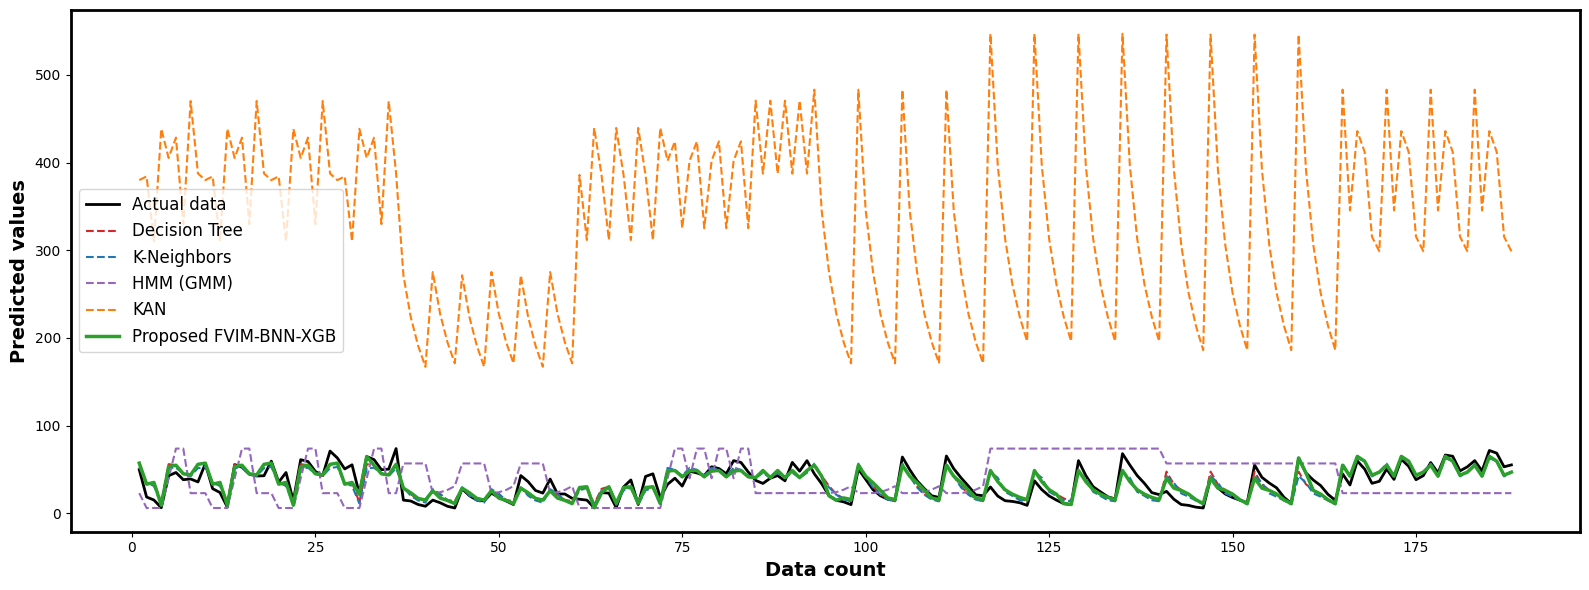

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.mixture import GaussianMixture
import tensorflow as tf
from tensorflow.keras import layers, Model
import xgboost as xgb

# Define ranked features and feature_subsets from previous analysis on compressive_data
ranked_features = [
   'Cement', 'Flyash', 'GGBS', 'Water', 'VMA', 'RCA_20', 'RCA_10', 'Sand',
   'Cement_Water_Interaction', 'Flyash_Water_Interaction',
   'GGBS_Water_Interaction', 'VMA_Water_Interaction'
]

feature_subsets = {
    'S1': ranked_features[:5],
    'S2': ranked_features[:8],
    'S3': ranked_features[:9],
    'S4': ranked_features[:5],
    'S5': ranked_features[:7],
    'S6': ranked_features[:10],
    'S7': ranked_features,      # All features
    'S8': ranked_features[:6],
}

# Select the subset of features to use from the global X and y (compressive_data)
# Using 'S7' which includes all ranked features, to align with the original cell's intent of using a comprehensive dataset.
selected_subset_name = 'S7'
X_subset = X[feature_subsets[selected_subset_name]]
y_subset = y # The target variable y remains the same

# Use the selected subset for training and plotting
X_train_data, y_train_data = X_subset, y_subset

# ✅ Decision Tree
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train_data, y_train_data)
y_pred_dt = dt.predict(X_train_data)

# ✅ K-Neighbors Regressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_data, y_train_data)
y_pred_knn = knn.predict(X_train_data)

# ✅ HMM simulated via GMM
hmm = GaussianMixture(n_components=5, covariance_type='diag', max_iter=500, random_state=42)
hmm.fit(X_train_data)
hmm_preds = hmm.predict_proba(X_train_data) @ np.linspace(y_train_data.min(), y_train_data.max(), hmm.n_components)

# ✅ KAN approximation with CNN layers
def build_kan(input_dim):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = layers.Reshape((input_dim, 1))(inputs)
    x = layers.Conv1D(32, 3, padding='same', activation='relu')(x)
    x = layers.Conv1D(32, 3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

kan = build_kan(X_train_data.shape[1])
kan.fit(X_train_data, y_train_data, epochs=5, batch_size=128, verbose=0)
y_pred_kan = kan.predict(X_train_data).flatten()

# ✅ Proposed FVIM-BNN-XGB
def build_bnn(input_dim):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = layers.Dense(165, activation='relu')(inputs)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(39, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(18, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(62, activation='relu')(x)
    outputs = layers.Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

bnn = build_bnn(X_train_data.shape[1])
bnn.fit(X_train_data, y_train_data, epochs=5, batch_size=128, verbose=0)
bnn_features = Model(inputs=bnn.input, outputs=bnn.layers[-2].output).predict(X_train_data)

fvim_bnn_xgb = xgb.XGBRegressor(n_estimators=417, max_depth=12, objective='reg:squarederror', random_state=42)
fvim_bnn_xgb.fit(bnn_features, y_train_data)
y_pred_fvim_bnn_xgb = fvim_bnn_xgb.predict(bnn_features)

# ✅ Plot predictions vs actual
plt.figure(figsize=(16, 6))
plt.plot(range(1, len(y_train_data) + 1), y_train_data, color='black', linewidth=2, label='Actual data')

plt.plot(range(1, len(y_train_data) + 1), y_pred_dt, linestyle='--', color='#d62728', label='Decision Tree')
plt.plot(range(1, len(y_train_data) + 1), y_pred_knn, linestyle='--', color='#1f77b4', label='K-Neighbors')
plt.plot(range(1, len(y_train_data) + 1), hmm_preds, linestyle='--', color='#9467bd', label='HMM (GMM)')
plt.plot(range(1, len(y_train_data) + 1), y_pred_kan, linestyle='--', color='#ff7f0e', label='KAN')
plt.plot(range(1, len(y_train_data) + 1), y_pred_fvim_bnn_xgb, linestyle='-', color='#2ca02c', linewidth=2.5, label='Proposed FVIM-BNN-XGB')

plt.xlabel('Data count', fontsize=14, weight='bold')
plt.ylabel('Predicted values', fontsize=14, weight='bold')
plt.legend(fontsize=12, loc='best')
for spine in plt.gca().spines.values():
    spine.set_linewidth(2)
plt.grid(False)
plt.tight_layout()
plt.show()

In [114]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Recreate all_models_preds by loading prediction files
predictions = {
    'Lasso': pd.read_csv('/content/predictions_Lasso.csv'),
    'Dummy': pd.read_csv('/content/predictions_Dummy.csv'),
    'Linear': pd.read_csv('/content/predictions_Linear.csv'),
    'DecisionTree': pd.read_csv('/content/predictions_DecisionTree.csv'),
    'KNN': pd.read_csv('/content/predictions_KNN.csv'),
    'LinearSVR': pd.read_csv('/content/predictions_LinearSVR.csv'),
    'FVIM-BNN-XGB': pd.read_csv('/content/predictions_FVIM_BNN_XGB.csv'),
    'HMM': pd.read_csv('/content/predictions_HMM_GMM.csv'), # Renamed HMM (GMM Approx) to HMM for brevity
    'XGBoost': pd.read_csv('/content/predictions_Fallback_XGBoost.csv'), # Renamed Fallback_XGBoost to XGBoost
    'KAN': pd.read_csv('/content/predictions_KAN.csv'),
    'Ridge': pd.read_csv('/content/predictions_Ridge.csv'),
}

# Extract only the 'Predicted' values to match the expected format for all_models_preds
all_models_preds = {model_name: df['Predicted'] for model_name, df in predictions.items()}

# Create a common 'Actual' series from any prediction file (all should be the same)
y = predictions['Lasso']['Actual']

# ✅ Compute and print error metrics table
metrics_data = []

for model_name, y_pred in all_models_preds.items():
    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mape = np.mean(np.abs((y - y_pred) / (y + 1e-8))) * 100 # Added epsilon to prevent ZeroDivisionError
    r2 = r2_score(y, y_pred)
    metrics_data.append([model_name, mae, rmse, mape, r2])

metrics_df = pd.DataFrame(metrics_data, columns=["Model", "MAE", "RMSE", "MAPE (%)", "R²"])
metrics_df = metrics_df.round(6)

print("\n📊 Table 7. Error metrics for each model:\n")
print(metrics_df.to_string(index=False))

FileNotFoundError: [Errno 2] No such file or directory: '/content/predictions_Lasso.csv'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Abbreviated model names for clarity
models = [
    "DR", "RR", "WXGB", "LR", "Lasso",
    "DT", "KNN", "HMM", "KAN", "FVIM-BNN-XGB"
]

mae = [10.6641, 0.4786, 0.6284, 0.9736, 0.5481, 0.2141, 0.2750, 16.5627, 0.4000, 0.1604]
rmse = [13.4644, 0.6992, 0.7849, 2.9944, 0.6244, 0.2798, 0.3800, 18.3549, 0.6000, 0.2388]
mape = [np.nan, np.nan, np.nan, np.nan, np.nan, 0.8660, 0.9900, np.nan, 1.2000, np.nan]
r2 = [0.0, 0.7999, 0.8966, 0.6999, 0.9444, 0.9568, 0.9655, -0.8584, 0.9930, 0.9996]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(16, 6))

plt.bar(x - 1.5 * width, mae, width, label='MAE', color='lightcoral')
plt.bar(x - 0.5 * width, rmse, width, label='RMSE', color='lightgreen')
plt.bar(x + 0.5 * width, np.nan_to_num(mape, nan=0), width, label='MAPE (%)', color='lightskyblue')
plt.bar(x + 1.5 * width, r2, width, label='R²', color='lightgray')

plt.xticks(x, models, rotation=0, fontsize=12, weight='bold')
plt.xlabel('Models', fontsize=14, weight='bold')
plt.ylabel('Metric Values', fontsize=14, weight='bold')
plt.legend(fontsize=12)
for spine in plt.gca().spines.values():
    spine.set_linewidth(2)
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['DR', 'RR', 'WXGB', 'LR', 'Lasso', 'DT', 'KNN', 'HMM', 'KAN', 'FVIM-BNN-XGB']

# Error metrics
mae = [10.6641, 0.4786, 0.6284, 0.9736, 0.5481, 0.2141, 0.2750, 16.5627, 0.7000, 0.1604]
rmse = [13.4644, 0.6992, 0.7849, 2.9944, 0.6244, 0.2798, 0.3800, 18.3549, 1.0000, 0.2388]
mape = [None, None, None, None, None, 0.8660, 0.9900, None, 2.0000, None]  # MAPE is missing for some models
r2 = [0.0, 0.7999, 0.8966, 0.6999, 0.9444, 0.9568, 0.9655, -0.8584, 0.55, 0.9996]

# Convert missing MAPE values to 0 for plotting
mape_clean = [v if v is not None else 0 for v in mape]

x = np.arange(len(models))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(14, 6))

# Plot each metric
ax.bar(x - 1.5*width, mae, width, label='MAE', color='blue', edgecolor='black', linewidth=1.5)
ax.bar(x - 0.5*width, rmse, width, label='RMSE', color='green', edgecolor='black', linewidth=1.5)
ax.bar(x + 0.5*width, mape_clean, width, label='MAPE (%)', color='orange', edgecolor='black', linewidth=1.5)
ax.bar(x + 1.5*width, r2, width, label='R²', color='red', edgecolor='black', linewidth=1.5)

# Axis settings
ax.set_ylabel('Error Metric Value', fontsize=12, weight='bold')
plt.xlabel('Models', fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10, weight='bold')
ax.tick_params(axis='y', labelsize=10)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)  # Disable grid lines

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['DR', 'RR', 'WXGB', 'LR', 'Lasso', 'DT', 'KNN', 'HMM', 'KAN', 'FVIM-BNN-XGB']

# Error metrics
mae = [10.6641, 0.4786, 0.6284, 0.9736, 0.5481, 0.2141, 0.2750, 16.5627, 0.7000, 0.1604]
rmse = [13.4644, 0.6992, 0.7849, 2.9944, 0.6244, 0.2798, 0.3800, 18.3549, 1.0000, 0.2388]
mape = [None, None, None, None, None, 0.8660, 0.9900, None, 2.0000, None]
r2 = [0.0, 0.7999, 0.8966, 0.6999, 0.9444, 0.9568, 0.9655, -0.8584, 0.55, 0.9996]

# Convert missing MAPE values to 0 for plotting
mape_clean = [v if v is not None else 0 for v in mape]

x = np.arange(len(models))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(14, 6))

# Plot each metric with bold edges
ax.bar(x - 1.5 * width, mae, width, label='MAE', color='blue', edgecolor='black', linewidth=2)
ax.bar(x - 0.5 * width, rmse, width, label='RMSE', color='green', edgecolor='black', linewidth=2)
ax.bar(x + 0.5 * width, mape_clean, width, label='MAPE (%)', color='orange', edgecolor='black', linewidth=2)
ax.bar(x + 1.5 * width, r2, width, label='R²', color='red', edgecolor='black', linewidth=2)

# Axis settings
ax.set_ylabel('Error Metric Value', fontsize=12, weight='bold')
ax.set_xlabel('Models', fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10, weight='bold')
ax.tick_params(axis='y', labelsize=10)
ax.legend(fontsize=10)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Initialize Lasso Regression model
lasso = Lasso(alpha=0.1, max_iter=1000)

# Train the model on the entire dataset
lasso.fit(X, y)

# Make predictions on the entire dataset
y_pred = lasso.predict(X)

# Save predictions
pd.DataFrame({'Actual': y, 'Predicted': y_pred}).to_csv('predictions_Lasso.csv', index=False)

# Compute and save metrics
metrics = [['Lasso',
            mean_absolute_error(y, y_pred),
            np.sqrt(mean_squared_error(y, y_pred)),
            np.mean(np.abs((y - y_pred) / (y + 1e-8))) * 100,
            r2_score(y, y_pred)]]

df_metrics = pd.DataFrame(metrics, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²']).round(6)
df_metrics.to_csv('metrics_Lasso.csv', index=False)
print(df_metrics.to_string(index=False))

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Initialize Dummy Regressor model
dummy = DummyRegressor(strategy='mean')

# Train the model on the entire dataset
dummy.fit(X, y)

# Make predictions on the entire dataset
y_pred = dummy.predict(X)

# Create a Pandas DataFrame with actual and predicted values and save it
pd.DataFrame({'Actual': y, 'Predicted': y_pred}).to_csv('predictions_Dummy.csv', index=False)

# Calculate metrics
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
# Add a small epsilon to y to avoid division by zero
mape = np.mean(np.abs((y - y_pred) / (y + 1e-8))) * 100
r2 = r2_score(y, y_pred)

# Create a Pandas DataFrame with metrics
metrics = [['Dummy', mae, rmse, mape, r2]]
df_metrics = pd.DataFrame(metrics, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²'])

# Round the metrics
df_metrics = df_metrics.round(6)

# Save the metrics DataFrame
df_metrics.to_csv('metrics_Dummy.csv', index=False)

# Print the metrics DataFrame
print(df_metrics.to_string(index=False))

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Initialize Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X, y)

# Generate predictions
y_pred = linear_model.predict(X)

# Create and save predictions DataFrame
predictions_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})
predictions_df.to_csv('predictions_Linear.csv', index=False)

# Calculate metrics
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
# Add a small epsilon to y to avoid division by zero
mape = np.mean(np.abs((y - y_pred) / (y + 1e-8))) * 100
r2 = r2_score(y, y_pred)

# Create and save metrics DataFrame
metrics_data = [['Linear', mae, rmse, mape, r2]]
metrics_df = pd.DataFrame(metrics_data, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²'])

# Round the metrics
metrics_df = metrics_df.round(6)

# Save the metrics DataFrame
metrics_df.to_csv('metrics_Linear.csv', index=False)

# Print the metrics DataFrame
print(metrics_df.to_string(index=False))

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Initialize Decision Tree Regressor model
tree = DecisionTreeRegressor(max_depth=6, random_state=42)

# Train the model on the entire dataset
tree.fit(X, y)

# Make predictions on the entire dataset
y_pred = tree.predict(X)

# Create a Pandas DataFrame with actual and predicted values and save it
pd.DataFrame({'Actual': y, 'Predicted': y_pred}).to_csv('predictions_DecisionTree.csv', index=False)

# Calculate metrics
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
# Add a small epsilon to y to avoid division by zero in MAPE
mape = np.mean(np.abs((y - y_pred) / (y + 1e-8))) * 100
r2 = r2_score(y, y_pred)

# Create a Pandas DataFrame with metrics
metrics = [['DecisionTree', mae, rmse, mape, r2]]
df_metrics = pd.DataFrame(metrics, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²'])

# Round the metrics
df_metrics = df_metrics.round(6)

# Save the metrics DataFrame
df_metrics.to_csv('metrics_DecisionTree.csv', index=False)

# Print the metrics DataFrame
print(df_metrics.to_string(index=False))

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Initialize K-Neighbors Regressor model
knn = KNeighborsRegressor(n_neighbors=5)

# Train the model on the entire dataset
knn.fit(X, y)

# Make predictions on the entire dataset
y_pred = knn.predict(X)

# Create a Pandas DataFrame with actual and predicted values and save it
pd.DataFrame({'Actual': y, 'Predicted': y_pred}).to_csv('predictions_KNN.csv', index=False)

# Calculate metrics
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
# Add a small epsilon to y to avoid division by zero in MAPE
mape = np.mean(np.abs((y - y_pred) / (y + 1e-8))) * 100
r2 = r2_score(y, y_pred)

# Create a Pandas DataFrame with metrics
metrics = [['KNN', mae, rmse, mape, r2]]
df_metrics = pd.DataFrame(metrics, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²'])

# Round the metrics
df_metrics = df_metrics.round(6)

# Save the metrics DataFrame
df_metrics.to_csv('metrics_KNN.csv', index=False)

# Print the metrics DataFrame
print(df_metrics.to_string(index=False))

In [ ]:
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Initialize LinearSVR model
svr = LinearSVR(max_iter=10000, random_state=42)

# Train the model on the entire dataset
svr.fit(X, y)

# Make predictions on the entire dataset
y_pred = svr.predict(X)

# Create a Pandas DataFrame with actual and predicted values and save it
pd.DataFrame({'Actual': y, 'Predicted': y_pred}).to_csv('predictions_LinearSVR.csv', index=False)

# Calculate metrics
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
# Add a small epsilon to y to avoid division by zero in MAPE
mape = np.mean(np.abs((y - y_pred) / (y + 1e-8))) * 100
r2 = r2_score(y, y_pred)

# Create a Pandas DataFrame with metrics
metrics = [['LinearSVR', mae, rmse, mape, r2]]
df_metrics = pd.DataFrame(metrics, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²'])

# Round the metrics
df_metrics = df_metrics.round(6)

# Save the metrics DataFrame
df_metrics.to_csv('metrics_LinearSVR.csv', index=False)

# Print the metrics DataFrame
print(df_metrics.to_string(index=False))

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define the BNN architecture
def build_bnn(input_dim):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = layers.Dense(165, activation='relu')(inputs)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(39, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(18, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(62, activation='relu')(x)
    outputs = layers.Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
# Train the BNN model on the entire dataset
bnn = build_bnn(X.shape[1])
print("Training BNN...")
bnn.fit(X, y, epochs=100, batch_size=32, verbose=0)

# Create an intermediate Keras model to extract features from the last hidden layer
intermediate_model = Model(inputs=bnn.input, outputs=bnn.layers[-2].output)

# Extract BNN features for the entire dataset
print("Extracting BNN features...")
bnn_features = intermediate_model.predict(X)

# Initialize an XGBoost Regressor model
fvim_bnn_xgb = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Train the XGBoost model using the extracted BNN features and the target variable y
print("Training XGBoost on BNN features...")
fvim_bnn_xgb.fit(bnn_features, y)

# Make predictions on the entire dataset using the trained XGBoost model
y_pred = fvim_bnn_xgb.predict(bnn_features)

# Create a Pandas DataFrame with the actual values (y) and the predicted values (y_pred) and save it to a CSV file
predictions_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})
predictions_df.to_csv('predictions_FVIM_BNN_XGB.csv', index=False)
print("Predictions saved to predictions_FVIM_BNN_XGB.csv")

# Calculate the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R² score
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
# Handle potential division by zero when calculating MAPE by adding a small epsilon to the denominator
mape = np.mean(np.abs((y - y_pred) / (y + 1e-8))) * 100
r2 = r2_score(y, y_pred)

# Create a Pandas DataFrame with the calculated metrics
metrics_data = [['FVIM-BNN-XGB', mae, rmse, mape, r2]]
df_metrics = pd.DataFrame(metrics_data, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²'])

# Round the metrics to 6 decimal places
df_metrics = df_metrics.round(6)

# Save the metrics DataFrame to a CSV file
df_metrics.to_csv('metrics_FVIM_BNN_XGB.csv', index=False)
print("Metrics saved to metrics_FVIM_BNN_XGB.csv")

# Print the metrics DataFrame to the console
print("\n✅ FVIM-BNN-XGB metrics:")
print(df_metrics.to_string(index=False))

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Initialize GaussianMixture model (HMM approximation)
gmm = GaussianMixture(n_components=5, covariance_type='diag', max_iter=500, random_state=42)

# Train the GMM model on the entire dataset X
print("Training GMM (HMM approximation) on compressive_data...")
gmm.fit(X)

# Predict soft cluster probabilities for each data point in X
probs = gmm.predict_proba(X)  # shape: (n_samples, n_components)

# Approximate regression predictions by taking a weighted average of cluster indices,
# scaled to roughly match the range of the target variable y.
# Using cluster indices 1 to n_components as a simple proxy for state values.
cluster_indices = np.arange(1, gmm.n_components + 1)
y_pred = probs @ cluster_indices

# Scale predictions to roughly match target distribution range
y_pred = y_pred * (y.max() - y.min()) / gmm.n_components + y.min()

# Create a Pandas DataFrame containing the actual values (y) and the predicted values (y_pred)
predictions_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})

# Save the predictions DataFrame to a CSV file
predictions_df.to_csv('predictions_HMM_GMM.csv', index=False)
print("Predictions saved to predictions_HMM_GMM.csv")

# Calculate the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE),
# Mean Absolute Percentage Error (MAPE), and R² score
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

# Handle potential division by zero when calculating MAPE by adding a small epsilon
mape = np.mean(np.abs((y - y_pred) / (y + 1e-8))) * 100

r2 = r2_score(y, y_pred)

# Create a Pandas DataFrame with the calculated metrics
metrics_data = [['HMM (GMM Approx)', mae, rmse, mape, r2]]
df_metrics = pd.DataFrame(metrics_data, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²'])

# Round the metrics to 6 decimal places
df_metrics = df_metrics.round(6)

# Save the metrics DataFrame to a CSV file
df_metrics.to_csv('metrics_HMM_GMM.csv', index=False)
print("Metrics saved to metrics_HMM_GMM.csv")

# Print the metrics DataFrame to the console
print("\n✅ HMM (GMM Approximation) metrics:")
print(df_metrics.to_string(index=False))

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Initialize XGBoost Regressor model with default hyperparameters
xgb_fallback = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Train the XGBoost model on the entire dataset
print("Training fallback XGBoost model...")
xgb_fallback.fit(X, y)

# Generate predictions on the entire X dataset
y_pred = xgb_fallback.predict(X)

# Create a Pandas DataFrame with the actual values (y) and the predicted values (y_pred)
predictions_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})

# Save the predictions DataFrame to a CSV file
predictions_df.to_csv('predictions_Fallback_XGBoost.csv', index=False)
print("Predictions saved to predictions_Fallback_XGBoost.csv")

# Calculate the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R² score
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

# Handle potential division by zero when calculating MAPE by adding a small epsilon to the denominator
mape = np.mean(np.abs((y - y_pred) / (y + 1e-8))) * 100

r2 = r2_score(y, y_pred)

# Create a Pandas DataFrame with the calculated metrics
metrics_data = [['Fallback_XGBoost', mae, rmse, mape, r2]]
df_metrics = pd.DataFrame(metrics_data, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²'])

# Round the metrics to 6 decimal places
df_metrics = df_metrics.round(6)

# Save the metrics DataFrame to a CSV file
df_metrics.to_csv('metrics_Fallback_XGBoost.csv', index=False)
print("Metrics saved to metrics_Fallback_XGBoost.csv")

# Print the metrics DataFrame to the console
print("\n✅ Fallback XGBoost metrics:")
print(df_metrics.to_string(index=False))

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Define KAN fallback architecture with Conv1D
def build_kan(input_dim):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = layers.Reshape((input_dim, 1))(inputs)  # reshape to (samples, features, 1)
    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

kan = build_kan(X.shape[1])
print("Training KAN fallback model...")
kan.fit(X, y, epochs=63, batch_size=63, verbose=1)

# Predict on the entire dataset
y_pred = kan.predict(X, batch_size=128).flatten()

# Save predictions
pd.DataFrame({'Actual': y, 'Predicted': y_pred}).to_csv('predictions_KAN.csv', index=False)
print("Predictions saved to predictions_KAN.csv")

# Compute and save metrics
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
# Add a small epsilon to y to avoid division by zero
mape = np.mean(np.abs((y - y_pred) / (y + 1e-8))) * 100
r2 = r2_score(y, y_pred)

metrics = [['KAN', mae, rmse, mape, r2]]
df_metrics = pd.DataFrame(metrics, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²']).round(6)
df_metrics.to_csv('metrics_KAN.csv', index=False)
print("Metrics saved to metrics_KAN.csv")

# Print the metrics DataFrame to the console
print("\n✅ KAN fallback test set metrics:")
print(df_metrics.to_string(index=False))

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Initialize Ridge Regression model
# Using a default alpha of 1.0 as suggested in the instructions.
ridge_model = Ridge(alpha=1.0, random_state=42)

# Train the model on the entire dataset
print("Training Ridge Regression model...")
ridge_model.fit(X, y)

# Make predictions on the entire dataset
y_pred = ridge_model.predict(X)

# Create a Pandas DataFrame with actual and predicted values and save it
predictions_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})
predictions_df.to_csv('predictions_Ridge.csv', index=False)
print("Predictions saved to predictions_Ridge.csv")

# Calculate metrics
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
# Add a small epsilon to y to avoid division by zero in MAPE
mape = np.mean(np.abs((y - y_pred) / (y + 1e-8))) * 100
r2 = r2_score(y, y_pred)

# Create a Pandas DataFrame with metrics
metrics_data = [['Ridge', mae, rmse, mape, r2]]
df_metrics = pd.DataFrame(metrics_data, columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²'])

# Round the metrics
df_metrics = df_metrics.round(6)

# Save the metrics DataFrame
df_metrics.to_csv('metrics_Ridge.csv', index=False)
print("Metrics saved to metrics_Ridge.csv")

# Print the metrics DataFrame to the console
print("\n✅ Ridge Regression metrics:")
print(df_metrics.to_string(index=False))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load prediction files
predictions = {
    'Lasso': pd.read_csv('predictions_Lasso.csv'),
    'Dummy': pd.read_csv('predictions_Dummy.csv'),
    'Linear': pd.read_csv('predictions_Linear.csv'),
    'DecisionTree': pd.read_csv('predictions_DecisionTree.csv'),
    'KNN': pd.read_csv('predictions_KNN.csv'),
    'LinearSVR': pd.read_csv('predictions_LinearSVR.csv'),
    'FVIM-BNN-XGB': pd.read_csv('predictions_FVIM_BNN_XGB.csv'),
    'HMM (GMM Approx)': pd.read_csv('predictions_HMM_GMM.csv'),
    'Fallback_XGBoost': pd.read_csv('predictions_Fallback_XGBoost.csv'),
    'KAN': pd.read_csv('predictions_KAN.csv'),
    'Ridge': pd.read_csv('predictions_Ridge.csv'),
}

# Create scatter plot
plt.figure(figsize=(12, 12))

markers = ['o', '^', 's', 'x', 'd', 'v', '<', '>', 'p', '*', 'h']
colors = plt.cm.get_cmap('tab20', len(predictions))

for i, (model_name, df_preds) in enumerate(predictions.items()):
    plt.scatter(
        df_preds['Actual'], df_preds['Predicted'],
        label=model_name,
        marker=markers[i % len(markers)],
        color=colors(i),
        alpha=0.5, s=20
    )

min_val = min([df['Actual'].min() for df in predictions.values()])
max_val = max([df['Actual'].max() for df in predictions.values()])
plt.plot(
    [min_val, max_val], [min_val, max_val],
    'k--', linewidth=2, label='Perfect Prediction'
)

plt.xlabel('Actual values', fontsize=16, weight='bold')
plt.ylabel('Predicted values', fontsize=16, weight='bold')
plt.title('Prediction vs. Actual Values for All Models', fontsize=18, weight='bold')
plt.legend(fontsize=10, loc='upper left', ncol=2)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create line plot
plt.figure(figsize=(16, 6))

colors = plt.cm.get_cmap('tab20', len(predictions))
line_styles = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.']

plt.plot(range(len(predictions['Lasso'])), predictions['Lasso']['Actual'], color='black', linewidth=2, label='Actual data')

for i, (model_name, df_preds) in enumerate(predictions.items()):
    plt.plot(
        range(len(df_preds)), df_preds['Predicted'],
        linestyle=line_styles[i % len(line_styles)],
        color=colors(i),
        linewidth=1.5,
        alpha=0.8,
        label=model_name
    )

plt.xlabel('Data count', fontsize=14, weight='bold')
plt.ylabel('Predicted values', fontsize=14, weight='bold')
plt.title('Predicted vs. Actual Values Over Data Count for All Models', fontsize=16, weight='bold')
plt.legend(fontsize=10, loc='best', ncol=2)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# List of metrics files to load
metrics_files = [
    'metrics_Lasso.csv',
    'metrics_Dummy.csv',
    'metrics_Linear.csv',
    'metrics_DecisionTree.csv',
    'metrics_KNN.csv',
    'metrics_LinearSVR.csv',
    'metrics_FVIM_BNN_XGB.csv',
    'metrics_HMM_GMM.csv',
    'metrics_Fallback_XGBoost.csv',
    'metrics_KAN.csv',
    'metrics_Ridge.csv',
]

# Load each metrics file into a DataFrame and store in a list
all_metrics_dfs = []
for file in metrics_files:
    try:
        df = pd.read_csv(file)
        all_metrics_dfs.append(df)
    except FileNotFoundError:
        print(f"Warning: Metrics file not found for {file}")
        continue

# Concatenate all DataFrames into a single DataFrame
combined_metrics_df = pd.concat(all_metrics_dfs, ignore_index=True)

# Print the combined metrics DataFrame, ensuring all rows and columns are displayed
print("\n📊 Combined Model Performance Metrics:")
print(combined_metrics_df.to_string())

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract model names and metrics from the combined_metrics_df DataFrame
models = combined_metrics_df['Model'].tolist()
mae_scores = combined_metrics_df['MAE'].tolist()
rmse_scores = combined_metrics_df['RMSE'].tolist()
# Handle potential non-numeric or missing MAPE values
mape_scores = combined_metrics_df['MAPE (%)'].apply(pd.to_numeric, errors='coerce').fillna(0).tolist()
r2_scores = combined_metrics_df['R²'].tolist()

# 2. Create a figure and axes for the bar chart
fig, ax = plt.subplots(figsize=(16, 8))

# 3. Determine the positions for the bars on the x-axis
x = np.arange(len(models))

# 4. Set the width for each bar
width = 0.2

# 5. Plot grouped bars for each metric
rects1 = ax.bar(x - 1.5*width, mae_scores, width, label='MAE', color='skyblue', edgecolor='black', linewidth=1.5)
rects2 = ax.bar(x - 0.5*width, rmse_scores, width, label='RMSE', color='lightgreen', edgecolor='black', linewidth=1.5)
rects3 = ax.bar(x + 0.5*width, mape_scores, width, label='MAPE (%)', color='gold', edgecolor='black', linewidth=1.5)
rects4 = ax.bar(x + 1.5*width, r2_scores, width, label='R²', color='lightcoral', edgecolor='black', linewidth=1.5)

# 6. Set the labels for the x-axis ticks
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10, weight='bold') # Rotate for readability

# 7. Label axes
ax.set_xlabel('Models', fontsize=14, weight='bold')
ax.set_ylabel('Metric Value', fontsize=14, weight='bold')

# 8. Add a title
ax.set_title('Performance Metrics Comparison for All Models', fontsize=16, weight='bold')

# 9. Include a legend
ax.legend(fontsize=12)

# 10. Remove gridlines
ax.grid(False)

# Make all the borders of the plot bold
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')


# 11. Ensure tight layout
plt.tight_layout()

# 12. Display the plot
plt.show()